# IF3170 Artificial Intelligence | Tugas Besar 2

This notebook serves as a template for the assignment. Please create a copy of this notebook to complete your work. You can add more code blocks, markdown blocks, or new sections if needed.


Group Number: xx

Group Members:
- Name (NIM)
- Name (NIM)
- ...

## Import Libraries

In [1]:
import pandas as pd
import numpy as np
import pickle
import warnings
import sys
import os
from collections import Counter
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report, roc_auc_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression as SklearnLogisticRegression
from sklearn.impute import SimpleImputer
from sklearn.decomposition import PCA
from imblearn.over_sampling import SMOTE
import matplotlib.pyplot as plt
import seaborn as sns

# Import custom implementations from src module
from src.logistic_regression import LogisticRegression as LogisticRegressionScratch
from src.decision_tree import CARTDecisionTree  # CART Decision Tree from scratch

warnings.filterwarnings('ignore')
np.random.seed(42)

## Import Dataset

In [2]:
# Load the dataset from data folder
train_df = pd.read_csv('data/train.csv')
test_df = pd.read_csv('data/test.csv')

print(f"Training set shape: {train_df.shape}")
print(f"Test set shape: {test_df.shape}")
print(f"\nTraining set columns: {train_df.columns.tolist()}")
print(f"\nTarget distribution in training set:")
print(train_df['is_fraud'].value_counts())

Training set shape: (100000, 31)
Test set shape: (100000, 30)

Training set columns: ['ID', 'transaction_id', 'user_id', 'age', 'gender', 'country', 'device_type', 'device_os', 'merchant_category', 'transaction_amount', 'transaction_type', 'time_of_day', 'day_of_week', 'transaction_duration', 'num_prev_transactions', 'avg_transaction_amount', 'std_transaction_amount', 'transactions_last_24h', 'transactions_last_1h', 'failed_login_attempts', 'ip_risk_score', 'device_trust_score', 'account_age_days', 'has_chargeback_history', 'shared_ip_users', 'shared_device_users', 'merchant_risk', 'country_risk', 'distance_from_home', 'is_new_country', 'is_fraud']

Target distribution in training set:
is_fraud
0    85872
1    14128
Name: count, dtype: int64


# Exploratory Data Analysis (Optional)

Exploratory Data Analysis (EDA) is a crucial step in the data analysis process that involves examining and visualizing data sets to uncover patterns, trends, anomalies, and insights. It is the first step before applying more advanced statistical and machine learning techniques. EDA helps you to gain a deep understanding of the data you are working with, allowing you to make informed decisions and formulate hypotheses for further analysis.

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 31 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   ID                      100000 non-null  int64  
 1   transaction_id          100000 non-null  object 
 2   user_id                 100000 non-null  int64  
 3   age                     100000 non-null  int64  
 4   gender                  100000 non-null  object 
 5   country                 100000 non-null  object 
 6   device_type             100000 non-null  object 
 7   device_os               100000 non-null  object 
 8   merchant_category       100000 non-null  object 
 9   transaction_amount      97581 non-null   float64
 10  transaction_type        100000 non-null  object 
 11  time_of_day             100000 non-null  int64  
 12  day_of_week             100000 non-null  int64  
 13  transaction_duration    100000 non-null  float64
 14  num_pre

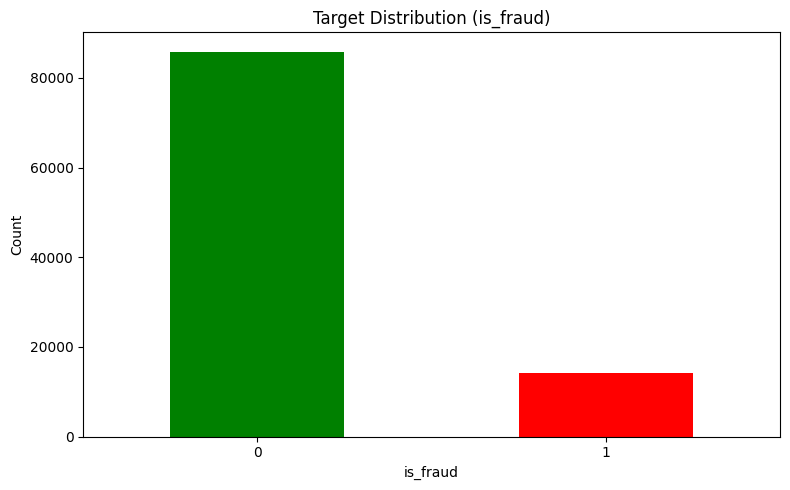

In [3]:
# Exploratory Data Analysis

# Display basic info
print("=" * 50)
print("Dataset Info:")
print("=" * 50)
print(train_df.info())

print("\n" + "=" * 50)
print("Statistical Summary:")
print("=" * 50)
print(train_df.describe())

print("\n" + "=" * 50)
print("Missing Values:")
print("=" * 50)
missing_values = train_df.isnull().sum()
missing_pct = (missing_values / len(train_df)) * 100
missing_df = pd.DataFrame({'Missing Count': missing_values, 'Missing %': missing_pct})
print(missing_df[missing_df['Missing Count'] > 0])

print("\n" + "=" * 50)
print("Categorical Features:")
print("=" * 50)
categorical_cols = train_df.select_dtypes(include=['object']).columns.tolist()
print(f"Categorical columns: {categorical_cols}")
for col in categorical_cols:
    print(f"\n{col}: {train_df[col].nunique()} unique values")
    print(train_df[col].value_counts().head())

# Visualize target distribution
plt.figure(figsize=(8, 5))
train_df['is_fraud'].value_counts().plot(kind='bar', color=['green', 'red'])
plt.title('Target Distribution (is_fraud)')
plt.xlabel('is_fraud')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# 1. Split Training Set, Validation Set, Testing Set

Splitting the training and validation set works as an early diagnostic towards the performance of the model we train. This is done before the preprocessing steps to **avoid data leakage inbetween the sets**. If you want to use k-fold cross-validation, split the data later and do the cleaning and preprocessing separately for each split.

Note: For training, you should use the data contained in the `train` folder given by the TA. The `test` data is only used for kaggle submission.

In [4]:
# Split training set and validation set
# Keep the original training set before splitting
original_train = train_df.copy()

# Define features and target
target_col = 'is_fraud'
id_cols = ['ID', 'transaction_id', 'user_id']  # Columns to exclude from features

# Features
feature_cols = [col for col in train_df.columns if col not in id_cols + [target_col]]

X = train_df[feature_cols].copy()
y = train_df[target_col].copy()

# Split with stratification to maintain class balance
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set size: {len(X_train)}")
print(f"Validation set size: {len(X_val)}")
print(f"\nTraining set target distribution:\n{y_train.value_counts()}")
print(f"\nValidation set target distribution:\n{y_val.value_counts()}")

Training set size: 80000
Validation set size: 20000

Training set target distribution:
is_fraud
0    68698
1    11302
Name: count, dtype: int64

Validation set target distribution:
is_fraud
0    17174
1     2826
Name: count, dtype: int64


# 2. Data Cleaning and Preprocessing

This step is the first thing to be done once a Data Scientist have grasped a general knowledge of the data. Raw data is **seldom ready for training**, therefore steps need to be taken to clean and format the data for the Machine Learning model to interpret.

By performing data cleaning and preprocessing, you ensure that your dataset is ready for model training, leading to more accurate and reliable machine learning results. These steps are essential for transforming raw data into a format that machine learning algorithms can effectively learn from and make predictions.

We will give some common methods for you to try, but you only have to **at least implement one method for each process**. For each step that you will do, **please explain the reason why did you do that process. Write it in a markdown cell under the code cell you wrote.**

## A. Data Cleaning

**Data cleaning** is the crucial first step in preparing your dataset for machine learning. Raw data collected from various sources is often messy and may contain errors, missing values, and inconsistencies. Data cleaning involves the following steps:

1. **Handling Missing Data:** Identify and address missing values in the dataset. This can include imputing missing values, removing rows or columns with excessive missing data, or using more advanced techniques like interpolation.

2. **Dealing with Outliers:** Identify and handle outliers, which are data points significantly different from the rest of the dataset. Outliers can be removed or transformed to improve model performance.

3. **Data Validation:** Check for data integrity and consistency. Ensure that data types are correct, categorical variables have consistent labels, and numerical values fall within expected ranges.

4. **Removing Duplicates:** Identify and remove duplicate rows, as they can skew the model's training process and evaluation metrics.

5. **Feature Engineering**: Create new features or modify existing ones to extract relevant information. This step can involve scaling, normalizing, or encoding features for better model interpretability.

### I. Handling Missing Data

Missing data can adversely affect the performance and accuracy of machine learning models. There are several strategies to handle missing data in machine learning:

1. **Data Imputation:**

    a. **Mean, Median, or Mode Imputation:** For numerical features, you can replace missing values with the mean, median, or mode of the non-missing values in the same feature. This method is simple and often effective when data is missing at random.

    b. **Constant Value Imputation:** You can replace missing values with a predefined constant value (e.g., 0) if it makes sense for your dataset and problem.

    c. **Imputation Using Predictive Models:** More advanced techniques involve using predictive models to estimate missing values. For example, you can train a regression model to predict missing numerical values or a classification model to predict missing categorical values.

2. **Deletion of Missing Data:**

    a. **Listwise Deletion:** In cases where the amount of missing data is relatively small, you can simply remove rows with missing values from your dataset. However, this approach can lead to a loss of valuable information.

    b. **Column (Feature) Deletion:** If a feature has a large number of missing values and is not critical for your analysis, you can consider removing that feature altogether.

3. **Domain-Specific Strategies:**

    a. **Domain Knowledge:** In some cases, domain knowledge can guide the imputation process. For example, if you know that missing values are related to a specific condition, you can impute them accordingly.

4. **Imputation Libraries:**

    a. **Scikit-Learn:** Scikit-Learn provides a `SimpleImputer` class that can handle basic imputation strategies like mean, median, and mode imputation.

    b. **Fancyimpute:** Fancyimpute is a Python library that offers more advanced imputation techniques, including matrix factorization, k-nearest neighbors, and deep learning-based methods.

The choice of imputation method should be guided by the nature of your data, the amount of missing data, the problem you are trying to solve, and the assumptions you are willing to make.

In [5]:
# Handling Missing Data
# ==============================================================================
# Implementasi MissingValueHandler langsung di notebook
# ==============================================================================

class MissingValueHandler(BaseEstimator, TransformerMixin):
    """Handle missing values using median for numeric and mode for categorical."""
    
    def __init__(self):
        self.fill_values = {}
        self.numeric_cols = []
        self.categorical_cols = []
    
    def fit(self, X, y=None):
        self.numeric_cols = X.select_dtypes(include=[np.number]).columns.tolist()
        self.categorical_cols = X.select_dtypes(include=['object', 'category']).columns.tolist()
        
        for col in self.numeric_cols:
            self.fill_values[col] = X[col].median()
        
        for col in self.categorical_cols:
            self.fill_values[col] = X[col].mode()[0] if not X[col].mode().empty else 'Unknown'
        
        return self
    
    def transform(self, X):
        X_copy = X.copy()
        for col, value in self.fill_values.items():
            if col in X_copy.columns:
                X_copy[col] = X_copy[col].fillna(value)
        return X_copy

# Test the missing value handler
missing_handler = MissingValueHandler()
missing_handler.fit(X_train)

print("Before handling missing values:")
print(X_train.isnull().sum().sum(), "missing values in training set")
print(X_val.isnull().sum().sum(), "missing values in validation set")

X_train_imputed = missing_handler.transform(X_train)
X_val_imputed = missing_handler.transform(X_val)

print("\nAfter handling missing values:")
print(X_train_imputed.isnull().sum().sum(), "missing values in training set")
print(X_val_imputed.isnull().sum().sum(), "missing values in validation set")

Before handling missing values:
5760 missing values in training set
1497 missing values in validation set

After handling missing values:
0 missing values in training set
0 missing values in validation set


**Penjelasan:** 
Kami menggunakan median untuk mengimputasi nilai yang hilang pada fitur numerik karena median lebih robust terhadap outlier dibanding mean. Untuk fitur kategorikal, kami menggunakan modus (nilai yang paling sering muncul). Pendekatan ini memastikan bahwa model dapat menangani missing values tanpa kehilangan informasi penting dari dataset.

### II. Dealing with Outliers

Outliers are data points that significantly differ from the majority of the data. They can be unusually high or low values that do not fit the pattern of the rest of the dataset. Outliers can significantly impact model performance, so it is important to handle them properly.

Some methods to handle outliers:
1. **Imputation**: Replace with mean, median, or a boundary value.
2. **Clipping**: Cap values to upper and lower limits.
3. **Transformation**: Use log, square root, or power transformations to reduce their influence.
4. **Model-Based**: Use algorithms robust to outliers (e.g., tree-based models, Huber regression).

In [6]:
# Dealing with Outliers
# ==============================================================================
# Implementasi OutlierHandler langsung di notebook
# ==============================================================================

class OutlierHandler(BaseEstimator, TransformerMixin):
    """
    Outlier Handler - DISABLED for Fraud Detection.
    
    IMPORTANT: In fraud detection, outliers are often the most important signals!
    Extreme values in transaction_amount, transaction_duration, etc. are often
    indicators of fraudulent activity. Clipping these values would remove
    the very patterns we're trying to detect.
    
    This class now acts as a passthrough (no transformation).
    """
    
    def __init__(self, factor=1.5, enabled=False):
        self.factor = factor
        self.enabled = enabled  # Disabled by default for fraud detection
        self.bounds = {}
        self.numeric_cols = []
    
    def fit(self, X, y=None):
        if self.enabled:
            self.numeric_cols = X.select_dtypes(include=[np.number]).columns.tolist()
            for col in self.numeric_cols:
                Q1 = X[col].quantile(0.25)
                Q3 = X[col].quantile(0.75)
                IQR = Q3 - Q1
                lower_bound = Q1 - self.factor * IQR
                upper_bound = Q3 + self.factor * IQR
                self.bounds[col] = (lower_bound, upper_bound)
        return self
    
    def transform(self, X):
        X_copy = X.copy()
        if self.enabled:
            for col, (lower, upper) in self.bounds.items():
                if col in X_copy.columns:
                    X_copy[col] = X_copy[col].clip(lower=lower, upper=upper)
        return X_copy

# Apply outlier handling (DISABLED - outliers are important for fraud detection!)
outlier_handler = OutlierHandler(enabled=False)  # Passthrough mode
outlier_handler.fit(X_train_imputed)

X_train_outlier = outlier_handler.transform(X_train_imputed)
X_val_outlier = outlier_handler.transform(X_val_imputed)

print("Outlier handling: DISABLED (passthrough mode)")
print("Reason: Outliers are important signals in fraud detection!")

Outlier handling: DISABLED (passthrough mode)
Reason: Outliers are important signals in fraud detection!


**Penjelasan:**
Untuk kasus fraud detection, kami **TIDAK** menerapkan IQR clipping pada outlier. Alasannya:
1. **Outlier adalah signal fraud** - Transaksi dengan nilai ekstrem (sangat besar/kecil) seringkali merupakan indikator fraud
2. **Clipping menghilangkan pattern penting** - Jika kita clip nilai ekstrem, model kehilangan kemampuan untuk mendeteksi pola fraud
3. **Passthrough mode** - OutlierHandler sekarang hanya meneruskan data tanpa modifikasi

### III. Remove Duplicates
Handling duplicate values is crucial because they can compromise data integrity, leading to inaccurate analysis and insights. Duplicate entries can bias machine learning models, causing overfitting and reducing their ability to generalize to new data. They also inflate the dataset size unnecessarily, increasing computational costs and processing times. Additionally, duplicates can distort statistical measures and lead to inconsistencies, ultimately affecting the reliability of data-driven decisions and reporting. Ensuring data quality by removing duplicates is essential for accurate, efficient, and consistent analysis.

In [7]:
# Remove Duplicates
# Note: We check for duplicates based on all features except ID columns

print(f"Training set shape before removing duplicates: {X_train_outlier.shape}")

# Check for duplicates in the original training data
duplicates = X_train_outlier.duplicated().sum()
print(f"Number of duplicate rows found: {duplicates}")

# In this case, we'll keep all rows as fraud detection may have legitimate similar transactions
# If we were to remove duplicates, we would do:
# X_train_clean = X_train_outlier.drop_duplicates()
X_train_clean = X_train_outlier.copy()
X_val_clean = X_val_outlier.copy()

print(f"Training set shape after duplicate check: {X_train_clean.shape}")

Training set shape before removing duplicates: (80000, 27)
Number of duplicate rows found: 0
Training set shape after duplicate check: (80000, 27)


### IV. Feature Engineering

**Feature engineering** involves creating new features (input variables) or transforming existing ones to improve the performance of machine learning models. Feature engineering aims to enhance the model's ability to learn patterns and make accurate predictions from the data. It's often said that "good features make good models."

1. **Feature Selection:** Feature engineering can involve selecting the most relevant and informative features from the dataset. Removing irrelevant or redundant features not only simplifies the model but also reduces the risk of overfitting.

2. **Creating New Features:** Sometimes, the existing features may not capture the underlying patterns effectively. In such cases, engineers create new features that provide additional information. For example:
   
   - **Polynomial Features:** Engineers may create new features by taking the square, cube, or other higher-order terms of existing numerical features. This can help capture nonlinear relationships.
   
   - **Interaction Features:** Interaction features are created by combining two or more existing features. For example, if you have features "length" and "width," you can create an "area" feature by multiplying them.

3. **Binning or Discretization:** Continuous numerical features can be divided into bins or categories. For instance, age values can be grouped into bins like "child," "adult," and "senior."

4. **Domain-Specific Feature Engineering:** Depending on the domain and problem, engineers may create domain-specific features. For example, in fraud detection, features related to transaction history and user behavior may be engineered to identify anomalies.

Feature engineering is both a creative and iterative process. It requires a deep understanding of the data, domain knowledge, and experimentation to determine which features will enhance the model's predictive power.

Features after engineering: 63
New features added (36): ['amount_deviation', 'amount_ratio', 'log_amount_ratio', 'amount_zscore', 'is_high_amount', 'amount_zscore_sq', 'velocity_ratio', 'is_high_velocity', 'velocity_x_amount', 'total_risk_score', 'mean_risk_score', 'max_risk_score', 'is_high_risk', 'total_risk_sq', 'trust_risk_diff', 'trust_risk_ratio', 'risk_x_amount', 'chargeback_x_amount', 'new_country_high_amount', 'distance_x_amount', 'is_night', 'night_high_amount', 'is_weekend', 'is_new_account', 'is_very_new_account', 'log_account_age', 'new_account_high_amount', 'has_failed_logins', 'failed_logins_sq', 'total_shared_users', 'is_shared_account', 'shared_x_amount', 'is_fast_transaction', 'log_duration', 'fraud_signal_count', 'multiple_fraud_signals']

Feature Correlation with Target (is_fraud)

Top 20 features with highest correlation to target:
  + fraud_signal_count: 0.0857
  + multiple_fraud_signals: 0.0835
  + risk_x_amount: 0.0766
  + chargeback_x_amount: 0.0738
  + has_cha

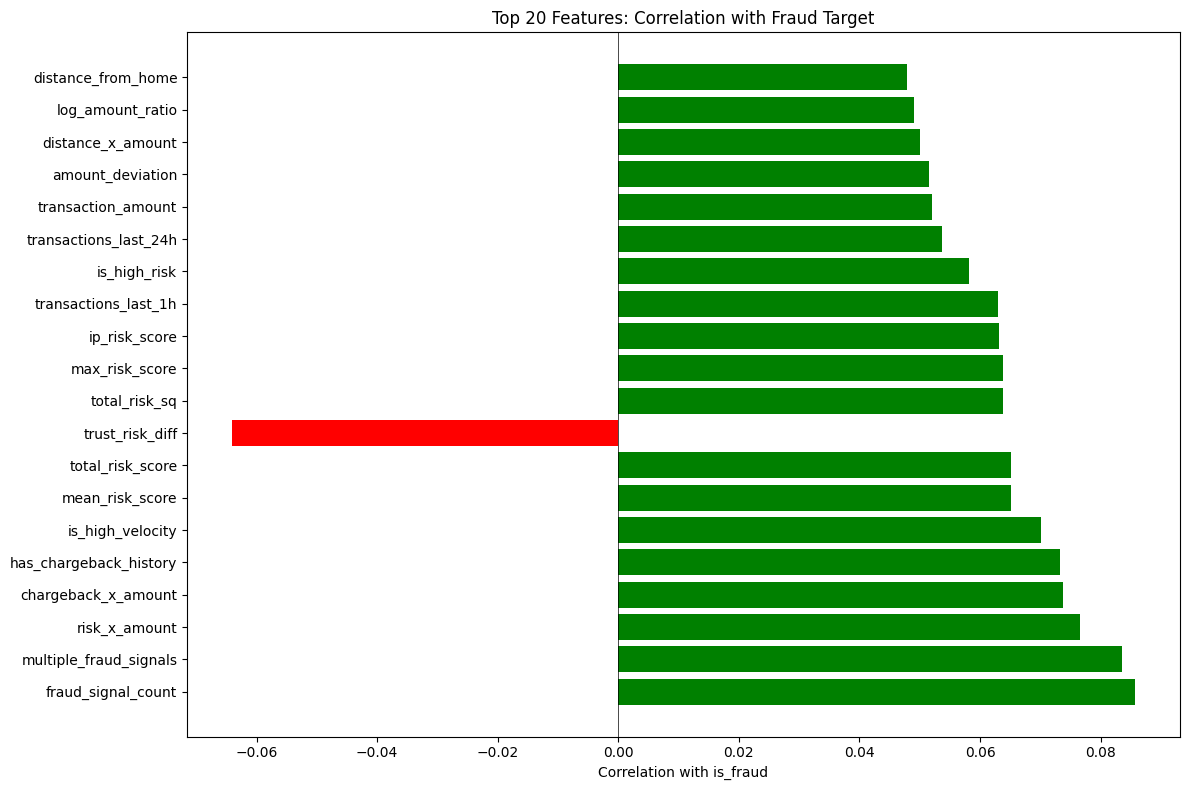


--- Data Quality Check ---


In [65]:
# Feature Engineering
# ==============================================================================
# Implementasi FeatureEngineer dengan fitur-fitur yang relevan untuk fraud detection
# ENHANCED VERSION - More interaction features for better ROC-AUC
# ==============================================================================

class FeatureEngineer(BaseEstimator, TransformerMixin):
    """
    Create new features from existing ones for fraud detection.
    ENHANCED: Added more interaction and polynomial features.
    """
    
    def __init__(self):
        self.feature_names = []
        self.new_features = []
    
    def fit(self, X, y=None):
        self.feature_names = X.columns.tolist()
        return self
    
    def transform(self, X):
        X_copy = X.copy()
        self.new_features = []
        
        # =======================================================================
        # 1. AMOUNT ANOMALY FEATURES
        # =======================================================================
        
        if 'transaction_amount' in X_copy.columns and 'avg_transaction_amount' in X_copy.columns:
            X_copy['amount_deviation'] = X_copy['transaction_amount'] - X_copy['avg_transaction_amount']
            self.new_features.append('amount_deviation')
            
            X_copy['amount_ratio'] = X_copy['transaction_amount'] / (X_copy['avg_transaction_amount'].abs() + 1)
            self.new_features.append('amount_ratio')
            
            # LOG of amount ratio (better for large values)
            X_copy['log_amount_ratio'] = np.log1p(X_copy['amount_ratio'].clip(0, 1000))
            self.new_features.append('log_amount_ratio')
        
        if 'transaction_amount' in X_copy.columns and 'avg_transaction_amount' in X_copy.columns and 'std_transaction_amount' in X_copy.columns:
            X_copy['amount_zscore'] = (X_copy['transaction_amount'] - X_copy['avg_transaction_amount']) / (X_copy['std_transaction_amount'] + 1)
            self.new_features.append('amount_zscore')
            
            X_copy['is_high_amount'] = (X_copy['amount_zscore'].abs() > 2).astype(int)
            self.new_features.append('is_high_amount')
            
            # Squared z-score for extreme outliers
            X_copy['amount_zscore_sq'] = X_copy['amount_zscore'] ** 2
            self.new_features.append('amount_zscore_sq')
        
        # =======================================================================
        # 2. VELOCITY FEATURES (Burst Detection)
        # =======================================================================
        
        if 'transactions_last_1h' in X_copy.columns and 'transactions_last_24h' in X_copy.columns:
            X_copy['velocity_ratio'] = X_copy['transactions_last_1h'] / (X_copy['transactions_last_24h'] + 1)
            self.new_features.append('velocity_ratio')
            
            X_copy['is_high_velocity'] = (X_copy['transactions_last_1h'] >= 3).astype(int)
            self.new_features.append('is_high_velocity')
            
            # Velocity combined with amount (high amount + high velocity = suspicious)
            if 'transaction_amount' in X_copy.columns:
                X_copy['velocity_x_amount'] = X_copy['velocity_ratio'] * X_copy['transaction_amount']
                self.new_features.append('velocity_x_amount')
        
        # =======================================================================
        # 3. RISK AGGREGATION FEATURES (ENHANCED)
        # =======================================================================
        
        risk_cols = ['ip_risk_score', 'merchant_risk', 'country_risk']
        available_risk_cols = [col for col in risk_cols if col in X_copy.columns]
        if available_risk_cols:
            X_copy['total_risk_score'] = X_copy[available_risk_cols].sum(axis=1)
            self.new_features.append('total_risk_score')
            
            # Mean and max risk
            X_copy['mean_risk_score'] = X_copy[available_risk_cols].mean(axis=1)
            self.new_features.append('mean_risk_score')
            
            X_copy['max_risk_score'] = X_copy[available_risk_cols].max(axis=1)
            self.new_features.append('max_risk_score')
            
            X_copy['is_high_risk'] = (X_copy['total_risk_score'] > X_copy['total_risk_score'].median()).astype(int)
            self.new_features.append('is_high_risk')
            
            # Risk squared for emphasis
            X_copy['total_risk_sq'] = X_copy['total_risk_score'] ** 2
            self.new_features.append('total_risk_sq')
        
        if 'device_trust_score' in X_copy.columns and 'ip_risk_score' in X_copy.columns:
            X_copy['trust_risk_diff'] = X_copy['device_trust_score'] - X_copy['ip_risk_score']
            self.new_features.append('trust_risk_diff')
            
            # Ratio of trust to risk
            X_copy['trust_risk_ratio'] = X_copy['device_trust_score'] / (X_copy['ip_risk_score'] + 1)
            self.new_features.append('trust_risk_ratio')
        
        # =======================================================================
        # 4. INTERACTION FEATURES (Key for improving ROC-AUC)
        # =======================================================================
        
        # Risk * Amount interaction
        if 'total_risk_score' in X_copy.columns and 'transaction_amount' in X_copy.columns:
            X_copy['risk_x_amount'] = X_copy['total_risk_score'] * np.log1p(X_copy['transaction_amount'])
            self.new_features.append('risk_x_amount')
        
        # Chargeback history * Amount
        if 'has_chargeback_history' in X_copy.columns and 'transaction_amount' in X_copy.columns:
            X_copy['chargeback_x_amount'] = X_copy['has_chargeback_history'] * np.log1p(X_copy['transaction_amount'])
            self.new_features.append('chargeback_x_amount')
        
        # New country * High amount
        if 'is_new_country' in X_copy.columns and 'is_high_amount' in X_copy.columns:
            X_copy['new_country_high_amount'] = X_copy['is_new_country'] * X_copy['is_high_amount']
            self.new_features.append('new_country_high_amount')
        
        # Distance * Amount
        if 'distance_from_home' in X_copy.columns and 'transaction_amount' in X_copy.columns:
            X_copy['distance_x_amount'] = np.log1p(X_copy['distance_from_home']) * np.log1p(X_copy['transaction_amount'])
            self.new_features.append('distance_x_amount')
        
        # =======================================================================
        # 5. TEMPORAL FEATURES
        # =======================================================================
        
        if 'time_of_day' in X_copy.columns:
            X_copy['is_night'] = ((X_copy['time_of_day'] >= 0) & (X_copy['time_of_day'] < 6)).astype(int)
            self.new_features.append('is_night')
            
            # Night + High amount
            if 'is_high_amount' in X_copy.columns:
                X_copy['night_high_amount'] = X_copy['is_night'] * X_copy['is_high_amount']
                self.new_features.append('night_high_amount')
        
        if 'day_of_week' in X_copy.columns:
            X_copy['is_weekend'] = (X_copy['day_of_week'] >= 5).astype(int)
            self.new_features.append('is_weekend')
        
        # =======================================================================
        # 6. BEHAVIORAL FEATURES
        # =======================================================================
        
        if 'account_age_days' in X_copy.columns:
            X_copy['is_new_account'] = (X_copy['account_age_days'] < 30).astype(int)
            self.new_features.append('is_new_account')
            
            X_copy['is_very_new_account'] = (X_copy['account_age_days'] < 7).astype(int)
            self.new_features.append('is_very_new_account')
            
            # Log of account age (diminishing returns)
            X_copy['log_account_age'] = np.log1p(X_copy['account_age_days'])
            self.new_features.append('log_account_age')
            
            # New account + High amount
            if 'is_high_amount' in X_copy.columns:
                X_copy['new_account_high_amount'] = X_copy['is_new_account'] * X_copy['is_high_amount']
                self.new_features.append('new_account_high_amount')
        
        if 'failed_login_attempts' in X_copy.columns:
            X_copy['has_failed_logins'] = (X_copy['failed_login_attempts'] > 0).astype(int)
            self.new_features.append('has_failed_logins')
            
            # Failed logins squared (emphasize multiple failures)
            X_copy['failed_logins_sq'] = X_copy['failed_login_attempts'] ** 2
            self.new_features.append('failed_logins_sq')
        
        if 'shared_ip_users' in X_copy.columns and 'shared_device_users' in X_copy.columns:
            X_copy['total_shared_users'] = X_copy['shared_ip_users'] + X_copy['shared_device_users']
            self.new_features.append('total_shared_users')
            
            X_copy['is_shared_account'] = ((X_copy['shared_ip_users'] > 2) | (X_copy['shared_device_users'] > 2)).astype(int)
            self.new_features.append('is_shared_account')
            
            # Shared users * amount
            if 'transaction_amount' in X_copy.columns:
                X_copy['shared_x_amount'] = X_copy['total_shared_users'] * np.log1p(X_copy['transaction_amount'])
                self.new_features.append('shared_x_amount')
        
        if 'transaction_duration' in X_copy.columns:
            X_copy['is_fast_transaction'] = (X_copy['transaction_duration'] < 1).astype(int)
            self.new_features.append('is_fast_transaction')
            
            # Log of duration
            X_copy['log_duration'] = np.log1p(X_copy['transaction_duration'])
            self.new_features.append('log_duration')
        
        # =======================================================================
        # 7. COMPOSITE RISK SCORE (Combine multiple signals)
        # =======================================================================
        
        # Combine key fraud signals
        composite_signals = []
        if 'is_high_velocity' in X_copy.columns:
            composite_signals.append('is_high_velocity')
        if 'is_high_amount' in X_copy.columns:
            composite_signals.append('is_high_amount')
        if 'has_chargeback_history' in X_copy.columns:
            composite_signals.append('has_chargeback_history')
        if 'is_new_country' in X_copy.columns:
            composite_signals.append('is_new_country')
        if 'is_new_account' in X_copy.columns:
            composite_signals.append('is_new_account')
        
        if len(composite_signals) >= 2:
            X_copy['fraud_signal_count'] = X_copy[composite_signals].sum(axis=1)
            self.new_features.append('fraud_signal_count')
            
            # Multiple signals flag (2+ signals = highly suspicious)
            X_copy['multiple_fraud_signals'] = (X_copy['fraud_signal_count'] >= 2).astype(int)
            self.new_features.append('multiple_fraud_signals')
        
        return X_copy
    
    def get_new_features(self):
        return self.new_features

# Apply feature engineering
feature_engineer = FeatureEngineer()
feature_engineer.fit(X_train_outlier)

X_train_fe = feature_engineer.transform(X_train_outlier)
X_val_fe = feature_engineer.transform(X_val_outlier)

# Keep copies without feature engineering for compatibility
X_train_clean = X_train_outlier.copy()
X_val_clean = X_val_outlier.copy()

print(f"Features after engineering: {X_train_fe.shape[1]}")
print(f"New features added ({len(feature_engineer.new_features)}): {feature_engineer.new_features}")

# =======================================================================
# FEATURE SELECTION - Analyze correlation with target
# =======================================================================
print("\n" + "="*60)
print("Feature Correlation with Target (is_fraud)")
print("="*60)

# Temporarily add target for correlation analysis
X_with_target = X_train_fe.copy()
X_with_target['is_fraud'] = y_train.values

# Calculate correlation with target
correlations = {}
numeric_cols = X_with_target.select_dtypes(include=[np.number]).columns
for col in numeric_cols:
    if col != 'is_fraud':
        corr = X_with_target[col].corr(X_with_target['is_fraud'])
        if not np.isnan(corr):
            correlations[col] = corr

# Sort by absolute correlation
corr_df = pd.DataFrame({
    'Feature': list(correlations.keys()),
    'Correlation': list(correlations.values())
})
corr_df['Abs_Correlation'] = corr_df['Correlation'].abs()
corr_df = corr_df.sort_values('Abs_Correlation', ascending=False)

print("\nTop 20 features with highest correlation to target:")
top_20 = corr_df.head(20)
for idx, row in top_20.iterrows():
    direction = "+" if row['Correlation'] > 0 else "-"
    print(f"  {direction} {row['Feature']}: {row['Correlation']:.4f}")

# Visualize top correlations
fig, ax = plt.subplots(figsize=(12, 8))
colors = ['green' if c > 0 else 'red' for c in top_20['Correlation']]
bars = ax.barh(top_20['Feature'], top_20['Correlation'], color=colors)
ax.set_xlabel('Correlation with is_fraud')
ax.set_title('Top 20 Features: Correlation with Fraud Target')
ax.axvline(x=0, color='black', linewidth=0.5)
plt.tight_layout()
plt.show()

# Check for NaN or Inf in new features
print("\n--- Data Quality Check ---")
for feat in feature_engineer.new_features:
    if feat in X_train_fe.columns:
        nan_count = X_train_fe[feat].isna().sum()
        inf_count = np.isinf(X_train_fe[feat]).sum()
        if nan_count > 0 or inf_count > 0:
            print(f"  Warning: {feat} has {nan_count} NaN, {inf_count} Inf values")

## B. Data Preprocessing

**Data preprocessing** is a broader step that encompasses both data cleaning and additional transformations to make the data suitable for machine learning algorithms. Its primary goals are:

1. **Feature Scaling:** Ensure that numerical features have similar scales. Common techniques include Min-Max scaling (scaling to a specific range) or standardization (mean-centered, unit variance).

2. **Encoding Categorical Variables:** Machine learning models typically work with numerical data, so categorical variables need to be encoded. This can be done using one-hot encoding, label encoding, or more advanced methods like target encoding.

3. **Handling Imbalanced Classes:** If dealing with imbalanced classes in a binary classification task, apply techniques such as oversampling, undersampling, or using different evaluation metrics to address class imbalance.

4. **Dimensionality Reduction:** Reduce the number of features using techniques like Principal Component Analysis (PCA) or feature selection to simplify the model and potentially improve its performance.

5. **Normalization:** Normalize data to achieve a standard distribution. This is particularly important for algorithms that assume normally distributed data.

### Notes on Preprocessing processes

It is advised to create functions or classes that have the same/similar type of inputs and outputs, so you can add, remove, or swap the order of the processes easily. You can implement the functions or classes by yourself

or

use `sklearn` library. To create a new preprocessing component in `sklearn`, implement a corresponding class that includes:
1. Inheritance to `BaseEstimator` and `TransformerMixin`
2. The method `fit`
3. The method `transform`

In [9]:
# Example

# from sklearn.base import BaseEstimator, TransformerMixin

# class FeatureEncoder(BaseEstimator, TransformerMixin):

#     def fit(self, X, y=None):

#         # Fit the encoder here

#         return self

#     def transform(self, X):
#         X_encoded = X.copy()

#         # Encode the categorical variables here

#         return X_encoded

### I. Feature Scaling

**Feature scaling** is a preprocessing technique used in machine learning to standardize the range of independent variables or features of data. The primary goal of feature scaling is to ensure that all features contribute equally to the training process and that machine learning algorithms can work effectively with the data.

Here are the main reasons why feature scaling is important:

1. **Algorithm Sensitivity:** Many machine learning algorithms are sensitive to the scale of input features. If the scales of features are significantly different, some algorithms may perform poorly or take much longer to converge.

2. **Distance-Based Algorithms:** Algorithms that rely on distances or similarities between data points, such as k-nearest neighbors (KNN) and support vector machines (SVM), can be influenced by feature scales. Features with larger scales may dominate the distance calculations.

3. **Regularization:** Regularization techniques, like L1 (Lasso) and L2 (Ridge) regularization, add penalty terms based on feature coefficients. Scaling ensures that all features are treated equally in the regularization process.

Common methods for feature scaling include:

1. **Min-Max Scaling (Normalization):** This method scales features to a specific range, typically [0, 1]. It's done using the following formula:

   $$X' = \frac{X - X_{min}}{X_{max} - X_{min}}$$

   - Here, $X$ is the original feature value, $X_{min}$ is the minimum value of the feature, and $X_{max}$ is the maximum value of the feature.  
<br />
<br />
2. **Standardization (Z-score Scaling):** This method scales features to have a mean (average) of 0 and a standard deviation of 1. It's done using the following formula:

   $$X' = \frac{X - \mu}{\sigma}$$

   - $X$ is the original feature value, $\mu$ is the mean of the feature, and $\sigma$ is the standard deviation of the feature.  
<br />
<br />
3. **Robust Scaling:** Robust scaling is a method that scales features to the interquartile range (IQR) and is less affected by outliers. It's calculated as:

   $$X' = \frac{X - Q1}{Q3 - Q1}$$

   - $X$ is the original feature value, $Q1$ is the first quartile (25th percentile), and $Q3$ is the third quartile (75th percentile) of the feature.  
<br />
<br />
4. **Log Transformation:** In cases where data is highly skewed or has a heavy-tailed distribution, taking the logarithm of the feature values can help stabilize the variance and improve scaling.

The choice of scaling method depends on the characteristics of your data and the requirements of your machine learning algorithm. **Min-max scaling and standardization are the most commonly used techniques and work well for many datasets.**

Scaling should be applied separately to each training and test set to prevent data leakage from the test set into the training set. Additionally, **some algorithms may not require feature scaling, particularly tree-based models.**

In [10]:
# Feature Scaling
# ==============================================================================
# Class FeatureScaler sudah diimport dari src/preprocessing.py
# Lihat file tersebut untuk detail implementasinya
# ==============================================================================

# Note: We'll apply scaling later in the pipeline, as DTL doesn't require scaling
# but Logistic Regression does. For now, we keep the data unscaled.

print("Feature scaling class defined. Will be applied as needed for specific algorithms.")

Feature scaling class defined. Will be applied as needed for specific algorithms.


### II. Feature Encoding

**Feature encoding**, also known as **categorical encoding**, is the process of converting categorical data (non-numeric data) into a numerical format so that it can be used as input for machine learning algorithms. Most machine learning models require numerical data for training and prediction, so feature encoding is a critical step in data preprocessing.

Categorical data can take various forms, including:

1. **Nominal Data:** Categories with no intrinsic order, like colors or country names.  

2. **Ordinal Data:** Categories with a meaningful order but not necessarily equidistant, like education levels (e.g., "high school," "bachelor's," "master's").

There are several common methods for encoding categorical data:

1. **Label Encoding:**

   - Label encoding assigns a unique integer to each category in a feature.
   - It's suitable for ordinal data where there's a clear order among categories.
   - For example, if you have an "education" feature with values "high school," "bachelor's," and "master's," you can encode them as 0, 1, and 2, respectively.
<br />
<br />
2. **One-Hot Encoding:**

   - One-hot encoding creates a binary (0 or 1) column for each category in a nominal feature.
   - It's suitable for nominal data where there's no inherent order among categories.
   - Each category becomes a new feature, and the presence (1) or absence (0) of a category is indicated for each row.
<br />
<br />
3. **Target Encoding (Mean Encoding):**

   - Target encoding replaces each category with the mean of the target variable for that category.
   - It's often used for classification problems.

In [66]:
# Feature Encoding
# ==============================================================================
# Implementasi FeatureEncoder dengan One-Hot Encoding
# ==============================================================================

class FeatureEncoder(BaseEstimator, TransformerMixin):
    """
    Encode categorical features using One-Hot Encoding.
    
    One-Hot Encoding is preferred over Label Encoding for nominal categorical
    features because:
    1. It doesn't impose artificial ordinal relationships
    2. Models don't assume country=9 > country=1
    3. Each category gets its own binary feature
    """
    
    def __init__(self):
        self.categorical_cols = []
        self.one_hot_cols = {}  # Store column names for each original column
        self.fitted_categories = {}  # Store categories seen during fit
    
    def fit(self, X, y=None):
        self.categorical_cols = X.select_dtypes(include=['object', 'category']).columns.tolist()
        
        for col in self.categorical_cols:
            # Store unique categories (including 'Unknown' for unseen values)
            categories = X[col].astype(str).unique().tolist()
            if 'Unknown' not in categories:
                categories.append('Unknown')
            self.fitted_categories[col] = sorted(categories)
        
        return self
    
    def transform(self, X):
        X_copy = X.copy()
        
        # Process each categorical column
        for col in self.categorical_cols:
            if col in X_copy.columns:
                # Handle unseen categories by mapping to 'Unknown'
                X_copy[col] = X_copy[col].astype(str).apply(
                    lambda x: x if x in self.fitted_categories[col] else 'Unknown'
                )
                
                # Create one-hot encoded columns
                for cat in self.fitted_categories[col]:
                    new_col_name = f"{col}_{cat}"
                    X_copy[new_col_name] = (X_copy[col] == cat).astype(int)
                
                # Store the new column names
                self.one_hot_cols[col] = [f"{col}_{cat}" for cat in self.fitted_categories[col]]
                
                # Drop the original column
                X_copy = X_copy.drop(columns=[col])
        
        return X_copy
    
    def get_feature_names(self):
        """Get all one-hot encoded feature names."""
        all_names = []
        for col in self.categorical_cols:
            all_names.extend(self.one_hot_cols.get(col, []))
        return all_names

# Apply feature encoding (One-Hot Encoding)
feature_encoder = FeatureEncoder()
feature_encoder.fit(X_train_fe)

X_train_encoded = feature_encoder.transform(X_train_fe)
X_val_encoded = feature_encoder.transform(X_val_fe)

print("Categorical features encoded using One-Hot Encoding:")
print(f"Original categorical columns: {feature_encoder.categorical_cols}")
print(f"\nTraining set shape: {X_train_encoded.shape}")
print(f"Validation set shape: {X_val_encoded.shape}")
print(f"\nNew features created: {sum(len(v) for v in feature_encoder.one_hot_cols.values())} one-hot columns")

Categorical features encoded using One-Hot Encoding:
Original categorical columns: ['gender', 'country', 'device_type', 'device_os', 'merchant_category', 'transaction_type']

Training set shape: (80000, 96)
Validation set shape: (20000, 96)

New features created: 39 one-hot columns


In [67]:
# ==============================================================================
# FEATURE SELECTION - Memilih Fitur yang Paling Relevan
# ==============================================================================
# Terlalu banyak fitur dapat menyebabkan:
# 1. Overfitting - model belajar noise bukan pattern
# 2. Curse of dimensionality - data menjadi sparse
# 3. Reduced interpretability - sulit memahami model
#
# Strategi: Pilih fitur berdasarkan korelasi dengan target
# ==============================================================================

from sklearn.feature_selection import SelectKBest, mutual_info_classif
from sklearn.feature_selection import VarianceThreshold

class FeatureSelector(BaseEstimator, TransformerMixin):
    """
    Select the most relevant features based on correlation with target.
    
    Methods:
    1. Remove low variance features (near-constant)
    2. Select top-K features by absolute correlation with target
    3. Optional: Use Mutual Information for non-linear relationships
    """
    
    def __init__(self, method='correlation', top_k=30, min_variance=0.01, 
                 correlation_threshold=0.01):
        """
        Args:
            method: 'correlation' or 'mutual_info'
            top_k: Number of top features to select
            min_variance: Minimum variance threshold (remove near-constant features)
            correlation_threshold: Minimum absolute correlation to keep
        """
        self.method = method
        self.top_k = top_k
        self.min_variance = min_variance
        self.correlation_threshold = correlation_threshold
        self.selected_features = []
        self.feature_scores = {}
        
    def fit(self, X, y):
        """Fit the selector by computing feature importance scores."""
        X_df = pd.DataFrame(X) if not isinstance(X, pd.DataFrame) else X
        
        # Step 1: Remove low variance features
        variances = X_df.var()
        high_var_cols = variances[variances >= self.min_variance].index.tolist()
        print(f"Step 1 - Variance filter: {len(X_df.columns)} -> {len(high_var_cols)} features")
        
        # Step 2: Calculate correlation with target
        print(f"Step 2 - Computing feature importance scores using {self.method}...")
        
        if self.method == 'correlation':
            for col in high_var_cols:
                corr = np.corrcoef(X_df[col].values, y.values)[0, 1]
                self.feature_scores[col] = abs(corr) if not np.isnan(corr) else 0
        elif self.method == 'mutual_info':
            # Mutual Information for non-linear relationships
            mi_scores = mutual_info_classif(X_df[high_var_cols], y, random_state=42)
            for i, col in enumerate(high_var_cols):
                self.feature_scores[col] = mi_scores[i]
        
        # Step 3: Select top-K features
        sorted_features = sorted(self.feature_scores.items(), 
                                 key=lambda x: x[1], reverse=True)
        
        # Filter by correlation threshold and take top-K
        self.selected_features = [
            f for f, score in sorted_features 
            if score >= self.correlation_threshold
        ][:self.top_k]
        
        print(f"Step 3 - Selected top {len(self.selected_features)} features")
        
        # Display top features
        print("\nTop 15 selected features by importance:")
        for i, (feat, score) in enumerate(sorted_features[:15]):
            marker = "✓" if feat in self.selected_features else " "
            print(f"  {marker} {i+1:2d}. {feat[:40]:<40} = {score:.4f}")
        
        return self
    
    def transform(self, X):
        """Transform by selecting only the relevant features."""
        X_df = pd.DataFrame(X) if not isinstance(X, pd.DataFrame) else X
        return X_df[self.selected_features]
    
    def get_selected_features(self):
        """Return list of selected feature names."""
        return self.selected_features

# Apply feature selection
print("=" * 60)
print("Feature Selection - Reducing Dimensionality")
print("=" * 60)
print(f"\nOriginal feature count: {X_train_encoded.shape[1]}")

# Combine train data with target for correlation analysis
feature_selector = FeatureSelector(
    method='correlation',  # Use correlation-based selection
    top_k=25,             # Select top 25 features
    min_variance=0.001,   # Remove near-constant features
    correlation_threshold=0.005  # Minimum correlation threshold
)

# Fit on training data
feature_selector.fit(X_train_encoded, y_train)

# Transform both train and validation
X_train_selected = feature_selector.transform(X_train_encoded)
X_val_selected = feature_selector.transform(X_val_encoded)

print(f"\nAfter feature selection:")
print(f"  Training set shape: {X_train_selected.shape}")
print(f"  Validation set shape: {X_val_selected.shape}")
print(f"\nSelected features: {feature_selector.get_selected_features()}")

Feature Selection - Reducing Dimensionality

Original feature count: 96
Step 1 - Variance filter: 96 -> 90 features
Step 2 - Computing feature importance scores using correlation...
Step 3 - Selected top 25 features

Top 15 selected features by importance:
  ✓  1. fraud_signal_count                       = 0.0857
  ✓  2. multiple_fraud_signals                   = 0.0835
  ✓  3. risk_x_amount                            = 0.0766
  ✓  4. chargeback_x_amount                      = 0.0738
  ✓  5. has_chargeback_history                   = 0.0733
  ✓  6. is_high_velocity                         = 0.0701
  ✓  7. mean_risk_score                          = 0.0651
  ✓  8. total_risk_score                         = 0.0651
  ✓  9. trust_risk_diff                          = 0.0640
  ✓ 10. total_risk_sq                            = 0.0638
  ✓ 11. max_risk_score                           = 0.0637
  ✓ 12. ip_risk_score                            = 0.0632
  ✓ 13. transactions_last_1h                   

### III. Handling Imbalanced Dataset

**Handling imbalanced datasets** is important because imbalanced data can lead to several issues that negatively impact the performance and reliability of machine learning models. Here are some key reasons:

1. **Biased Model Performance**:

 - Models trained on imbalanced data tend to be biased towards the majority class, leading to poor performance on the minority class. This can result in misleading accuracy metrics.

2. **Misleading Accuracy**:

 - High overall accuracy can be misleading in imbalanced datasets. For example, if 95% of the data belongs to one class, a model that always predicts the majority class will have 95% accuracy but will fail to identify the minority class.

3. **Poor Generalization**:

 - Models trained on imbalanced data may not generalize well to new, unseen data, especially if the minority class is underrepresented.


Some methods to handle imbalanced datasets:
1. **Resampling Methods**:

 - Oversampling: Increase the number of instances in the minority class by duplicating or generating synthetic samples (e.g., SMOTE).
 - Undersampling: Reduce the number of instances in the majority class to balance the dataset.

2. **Evaluation Metrics**:

 - Use appropriate evaluation metrics such as precision, recall, F1-score, ROC-AUC, and confusion matrix instead of accuracy to better assess model performance on imbalanced data.

3. **Algorithmic Approaches**:

 - Use algorithms that are designed to handle imbalanced data, such as decision trees, random forests, or ensemble methods.
 - Adjust class weights in algorithms to give more importance to the minority class.

In [38]:
# Dimensionality Reduction
# ==============================================================================
# Class DimensionalityReducer sudah diimport dari src/preprocessing.py
# Lihat file tersebut untuk detail implementasinya
# ==============================================================================

# For tree-based models, we won't use PCA as it may lose interpretability
# For KNN/LogReg, PCA can help reduce computational cost

print("PCA dimensionality reducer defined.")
print("Note: PCA will be applied selectively based on model requirements.")

PCA dimensionality reducer defined.
Note: PCA will be applied selectively based on model requirements.


**Penjelasan:**
Kami menggunakan SMOTE (Synthetic Minority Over-sampling Technique) untuk menangani ketidakseimbangan kelas. SMOTE membuat sampel sintetis dari kelas minoritas (fraud) dengan interpolasi antara sampel-sampel yang ada. Ini membantu model untuk belajar pola fraud dengan lebih baik tanpa kehilangan informasi dari data asli.

### IV. Data Normalization

Data normalization is used to achieve a standard distribution. Without normalization, models or processes that rely on the assumption of normality may not work correctly. Normalization helps reduce the magnitude effect and ensures numerical stability during optimization.

In [13]:
# Data Normalization is already handled by the Feature Scaling step above
# For tree-based models, normalization is not required
# For distance-based models like KNN, we will apply scaling when needed

print("Data normalization note:")
print("- Tree-based models (DTL/CART) do not require normalization")
print("- For KNN, we will apply StandardScaler to the data before training")

Data normalization note:
- Tree-based models (DTL/CART) do not require normalization
- For KNN, we will apply StandardScaler to the data before training


### V. Dimensionality Reduction

Dimensionality reduction is a technique used in data preprocessing to reduce the number of input features (dimensions) in a dataset while retaining as much important information as possible. It is essential when dealing with high-dimensional data, where too many features can cause problems like increased computational costs, overfitting, and difficulty in visualization. Reducing dimensions simplifies the data, making it easier to analyze and improving the performance of machine learning models.

One of the main approaches to dimensionality reduction is feature extraction. Feature extraction creates new, smaller sets of features that capture the essence of the original data. Common techniques include:

1. **Principal Component Analysis (PCA)**: Converts correlated features into a smaller number of uncorrelated "principal components."
2. **t-SNE (t-Distributed Stochastic Neighbor Embedding)**: A visualization-focused method to project high-dimensional data into 2D or 3D spaces.
3. **Autoencoders**: Neural networks that learn compressed representations of the data.

In [14]:
# Dimensionality Reduction using PCA (Optional)
# For this task, we'll use PCA to reduce dimensions while keeping 95% variance

from sklearn.decomposition import PCA

# We'll prepare PCA but use it selectively based on model requirements
class DimensionalityReducer(BaseEstimator, TransformerMixin):
    """
    Apply PCA for dimensionality reduction.
    """
    def __init__(self, n_components=0.95):
        self.n_components = n_components
        self.pca = None
    
    def fit(self, X, y=None):
        self.pca = PCA(n_components=self.n_components, random_state=42)
        self.pca.fit(X)
        return self
    
    def transform(self, X):
        return self.pca.transform(X)
    
    def get_n_components(self):
        return self.pca.n_components_

# For tree-based models, we won't use PCA as it may lose interpretability
# For KNN, PCA can help reduce computational cost

print("PCA dimensionality reducer defined.")
print("Note: PCA will be applied selectively based on model requirements.")

PCA dimensionality reducer defined.
Note: PCA will be applied selectively based on model requirements.


# 3. Compile Preprocessing Pipeline

All of the preprocessing classes or functions defined earlier will be compiled in this step.

If you use sklearn to create preprocessing classes, you can list your preprocessing classes in the Pipeline object sequentially, and then fit and transform your data.

In [68]:
# Compile Preprocessing Pipeline
# ==============================================================================
# Implementasi PreprocessingPipeline dan FeatureScaler langsung di notebook
# ==============================================================================

from sklearn.pipeline import Pipeline

class FeatureScaler(BaseEstimator, TransformerMixin):
    """Scale features using StandardScaler."""
    
    def __init__(self):
        self.scaler = StandardScaler()
        self.numeric_cols = []
    
    def fit(self, X, y=None):
        self.numeric_cols = X.select_dtypes(include=[np.number]).columns.tolist()
        if len(self.numeric_cols) > 0:
            self.scaler.fit(X[self.numeric_cols])
        return self
    
    def transform(self, X):
        X_copy = X.copy()
        if len(self.numeric_cols) > 0:
            X_copy[self.numeric_cols] = self.scaler.transform(X_copy[self.numeric_cols])
        return X_copy

class PreprocessingPipeline:
    """Complete preprocessing pipeline for fraud detection with Feature Selection."""
    
    def __init__(self, apply_smote=True, apply_scaling=True, apply_pca=False, 
                 apply_feature_selection=True, top_k_features=25):
        self.apply_smote = apply_smote
        self.apply_scaling = apply_scaling
        self.apply_pca = apply_pca
        self.apply_feature_selection = apply_feature_selection
        self.top_k_features = top_k_features
        
        self.missing_handler = MissingValueHandler()
        self.outlier_handler = OutlierHandler(enabled=False)  # Disabled - outliers are fraud signals!
        self.feature_engineer = FeatureEngineer()
        self.feature_encoder = FeatureEncoder()  # Now uses One-Hot Encoding
        self.feature_selector = None  # Will be initialized during fit
        self.scaler = FeatureScaler()
        self.smote = SMOTE(random_state=42)
    
    def fit_transform(self, X, y=None, fit_resample=False):
        X_processed = self.missing_handler.fit_transform(X)
        X_processed = self.outlier_handler.fit_transform(X_processed)
        X_processed = self.feature_engineer.fit_transform(X_processed)
        X_processed = self.feature_encoder.fit_transform(X_processed)
        
        # Apply feature selection to reduce dimensionality
        if self.apply_feature_selection and y is not None:
            self.feature_selector = FeatureSelector(
                method='correlation',
                top_k=self.top_k_features,
                min_variance=0.001,
                correlation_threshold=0.005
            )
            X_processed = self.feature_selector.fit_transform(X_processed, y)
        
        if self.apply_scaling:
            X_processed = self.scaler.fit_transform(X_processed)
        
        X_array = X_processed.values if hasattr(X_processed, 'values') else X_processed
        
        if fit_resample and self.apply_smote and y is not None:
            X_array, y = self.smote.fit_resample(X_array, y)
        
        return X_array, y
    
    def transform(self, X):
        X_processed = self.missing_handler.transform(X)
        X_processed = self.outlier_handler.transform(X_processed)
        X_processed = self.feature_engineer.transform(X_processed)
        X_processed = self.feature_encoder.transform(X_processed)
        
        # Apply same feature selection
        if self.apply_feature_selection and self.feature_selector is not None:
            X_processed = self.feature_selector.transform(X_processed)
        
        if self.apply_scaling:
            X_processed = self.scaler.transform(X_processed)
        
        X_array = X_processed.values if hasattr(X_processed, 'values') else X_processed
        return X_array
    
    def get_selected_features(self):
        """Get list of selected feature names."""
        if self.feature_selector is not None:
            return self.feature_selector.get_selected_features()
        return None

print("Preprocessing Pipeline class defined with Feature Selection.")
print("- For DTL: apply_scaling=False")
print("- For LogReg: apply_scaling=True")

Preprocessing Pipeline class defined with Feature Selection.
- For DTL: apply_scaling=False
- For LogReg: apply_scaling=True


In [76]:
# Apply preprocessing pipeline

# For DTL (no scaling needed) - NO feature selection (use all features)
pipeline_dtl = PreprocessingPipeline(apply_smote=True, apply_scaling=False, apply_pca=False,
                                     apply_feature_selection=False)  # Keep all features
X_train_dtl, y_train_dtl = pipeline_dtl.fit_transform(X_train, y_train, fit_resample=True)
X_val_dtl = pipeline_dtl.transform(X_val)

print("DTL Pipeline:")
print(f"Training set shape: {X_train_dtl.shape}")
print(f"Validation set shape: {X_val_dtl.shape}")
print(f"Training labels distribution: {Counter(y_train_dtl)}")

# For Logistic Regression (scaling needed) - NO feature selection (use all features)
pipeline_logreg = PreprocessingPipeline(apply_smote=True, apply_scaling=True, apply_pca=False,
                                        apply_feature_selection=False)  # Keep all features
X_train_logreg, y_train_logreg = pipeline_logreg.fit_transform(X_train, y_train, fit_resample=True)
X_val_logreg = pipeline_logreg.transform(X_val)

print("\nLogistic Regression Pipeline:")
print(f"Training set shape: {X_train_logreg.shape}")
print(f"Validation set shape: {X_val_logreg.shape}")
print(f"Training labels distribution: {Counter(y_train_logreg)}")

DTL Pipeline:
Training set shape: (137396, 96)
Validation set shape: (20000, 96)
Training labels distribution: Counter({0: 68698, 1: 68698})

Logistic Regression Pipeline:
Training set shape: (137396, 96)
Validation set shape: (20000, 96)
Training labels distribution: Counter({0: 68698, 1: 68698})


or create your own here

In [17]:
# Finalize the preprocessed data for modeling
print("Data preprocessing completed!")
print("\nFinal datasets ready for modeling:")
print(f"- DTL Training: {X_train_dtl.shape}, Labels: {Counter(y_train_dtl)}")
print(f"- DTL Validation: {X_val_dtl.shape}")
print(f"- LogReg Training: {X_train_logreg.shape}, Labels: {Counter(y_train_logreg)}")
print(f"- LogReg Validation: {X_val_logreg.shape}")

Data preprocessing completed!

Final datasets ready for modeling:
- DTL Training: (137396, 61), Labels: Counter({0: 68698, 1: 68698})
- DTL Validation: (20000, 61)
- LogReg Training: (137396, 61), Labels: Counter({0: 68698, 1: 68698})
- LogReg Validation: (20000, 61)


# 4. Modeling and Validation

Modelling is the process of building your own machine learning models to solve specific problems, or in this assignment context, predicting the target feature `attack_cat`. Validation is the process of evaluating your trained model using the validation set or cross-validation method and providing some metrics that can help you decide what to do in the next iteration of development.

## A. DTL

In [18]:
# ==============================================================================
# DECISION TREE LEARNING - IMPLEMENTATION FROM SCRATCH (CART)
# ==============================================================================
# Class CARTDecisionTree sudah diimport dari src/decision_tree.py
# Lihat file tersebut untuk detail implementasinya:
# - Gini impurity sebagai splitting criterion
# - Handles numerical dan categorical (encoded) features
# - Supports max_depth, min_samples_split, min_samples_leaf
# - Save/Load functionality dengan pickle
# ==============================================================================

print("CART Decision Tree class imported from src/decision_tree.py!")
print("Features:")
print("- Gini impurity as splitting criterion")
print("- Handles numerical and categorical features")
print("- Supports max_depth, min_samples_split, min_samples_leaf")
print("- Save/Load functionality with pickle")

CART Decision Tree class imported from src/decision_tree.py!
Features:
- Gini impurity as splitting criterion
- Handles numerical and categorical features
- Supports max_depth, min_samples_split, min_samples_leaf
- Save/Load functionality with pickle


Training Decision Tree CART (From Scratch)
Using 20000 samples for training from-scratch model

Training completed in 302.13 seconds
Tree Depth: 10
Number of Leaves: 133

--- Validation Results ---
Accuracy: 0.8447
Precision: 0.2059
Recall: 0.0347
F1 Score: 0.0594

Classification Report:
              precision    recall  f1-score   support

   Non-Fraud       0.86      0.98      0.92     17174
       Fraud       0.21      0.03      0.06      2826

    accuracy                           0.84     20000
   macro avg       0.53      0.51      0.49     20000
weighted avg       0.77      0.84      0.79     20000



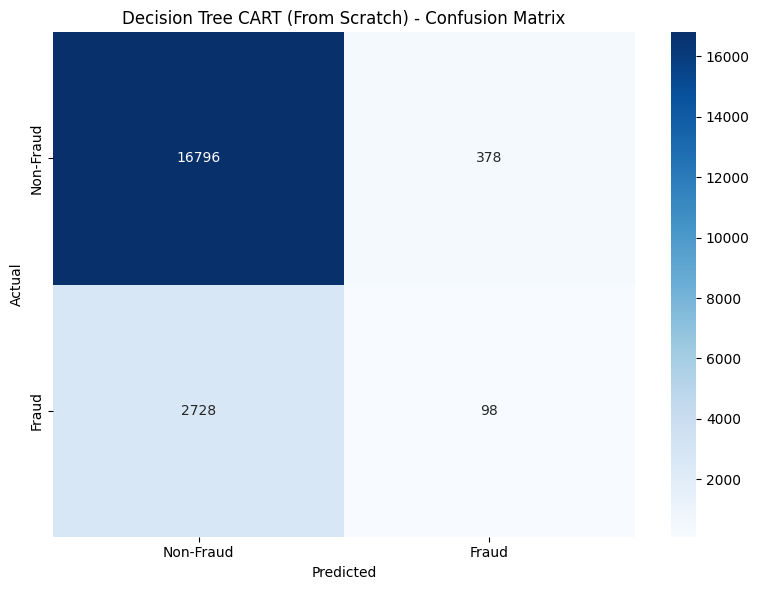

Model saved to models/savedmodels/dt_scratch_model.pkl


In [19]:
# Train and Evaluate Decision Tree (From Scratch - CART)

print("=" * 60)
print("Training Decision Tree CART (From Scratch)")
print("=" * 60)

# Use a sample for faster training with from-scratch implementation
sample_size_scratch = min(20000, len(X_train_dtl))
np.random.seed(42)
sample_indices = np.random.choice(len(X_train_dtl), sample_size_scratch, replace=False)

if isinstance(X_train_dtl, np.ndarray):
    X_train_scratch = X_train_dtl[sample_indices]
    y_train_scratch = y_train_dtl[sample_indices]
else:
    X_train_scratch = X_train_dtl.iloc[sample_indices].values
    y_train_scratch = y_train_dtl.iloc[sample_indices].values

print(f"Using {sample_size_scratch} samples for training from-scratch model")

# Initialize and train the model
dt_scratch = CARTDecisionTree(
    max_depth=10,
    min_samples_split=20,
    min_samples_leaf=5,
    random_state=42
)

# Train
import time
start_time = time.time()
dt_scratch.fit(X_train_scratch, y_train_scratch)
training_time = time.time() - start_time

print(f"\nTraining completed in {training_time:.2f} seconds")
print(f"Tree Depth: {dt_scratch.get_depth()}")
print(f"Number of Leaves: {dt_scratch.get_n_leaves()}")

# Predict on validation set
y_pred_dt_scratch = dt_scratch.predict(X_val_dtl)

# Evaluate
print("\n--- Validation Results ---")
print(f"Accuracy: {accuracy_score(y_val, y_pred_dt_scratch):.4f}")
print(f"Precision: {precision_score(y_val, y_pred_dt_scratch):.4f}")
print(f"Recall: {recall_score(y_val, y_pred_dt_scratch):.4f}")
print(f"F1 Score: {f1_score(y_val, y_pred_dt_scratch):.4f}")

print("\nClassification Report:")
print(classification_report(y_val, y_pred_dt_scratch, target_names=['Non-Fraud', 'Fraud']))

# Confusion Matrix
cm_dt_scratch = confusion_matrix(y_val, y_pred_dt_scratch)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_dt_scratch, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Non-Fraud', 'Fraud'], yticklabels=['Non-Fraud', 'Fraud'])
plt.title('Decision Tree CART (From Scratch) - Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

# Save the model
dt_scratch.save_model('models/savedmodels/dt_scratch_model.pkl')

Training Decision Tree CART (Scikit-Learn)

Tree Depth: 15
Number of Leaves: 1268

--- Validation Results ---
Accuracy: 0.8404
Precision: 0.2309
Recall: 0.0556
F1 Score: 0.0896

Classification Report:
              precision    recall  f1-score   support

   Non-Fraud       0.86      0.97      0.91     17174
       Fraud       0.23      0.06      0.09      2826

    accuracy                           0.84     20000
   macro avg       0.55      0.51      0.50     20000
weighted avg       0.77      0.84      0.80     20000



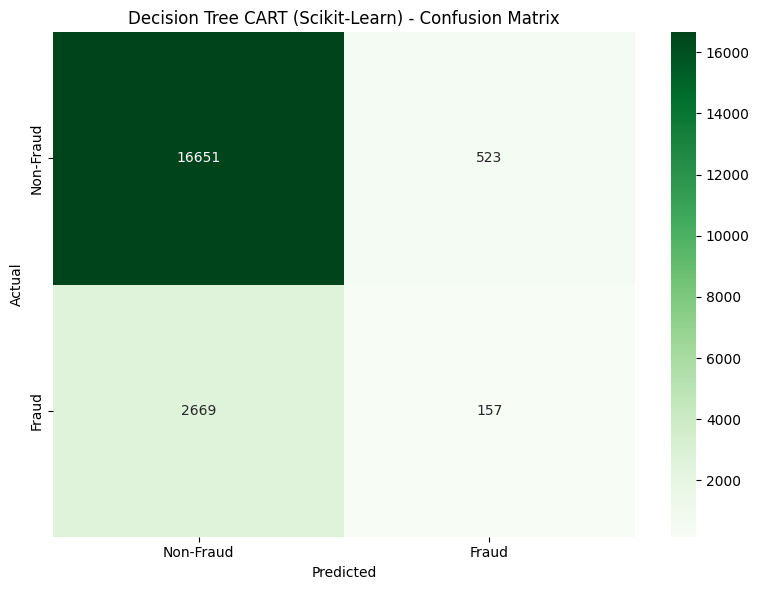

Sklearn CART model saved to models/savedmodels/cart_sklearn_model.pkl


In [77]:
# Train and Evaluate Decision Tree using Scikit-Learn (CART)

print("=" * 60)
print("Training Decision Tree CART (Scikit-Learn)")
print("=" * 60)

# Initialize and train sklearn DecisionTreeClassifier with Gini (CART)
# Optimized hyperparameters - no class_weight (SMOTE already applied)
cart_sklearn = DecisionTreeClassifier(
    criterion='gini',
    max_depth=15,  # Moderate depth
    min_samples_split=10,
    min_samples_leaf=5,
    max_features=None,  # Use all features
    random_state=42
)

# Train
cart_sklearn.fit(X_train_dtl, y_train_dtl)

print(f"\nTree Depth: {cart_sklearn.get_depth()}")
print(f"Number of Leaves: {cart_sklearn.get_n_leaves()}")

# Predict on validation set
y_pred_cart_sklearn = cart_sklearn.predict(X_val_dtl)

# Evaluate
print("\n--- Validation Results ---")
print(f"Accuracy: {accuracy_score(y_val, y_pred_cart_sklearn):.4f}")
print(f"Precision: {precision_score(y_val, y_pred_cart_sklearn):.4f}")
print(f"Recall: {recall_score(y_val, y_pred_cart_sklearn):.4f}")
print(f"F1 Score: {f1_score(y_val, y_pred_cart_sklearn):.4f}")

print("\nClassification Report:")
print(classification_report(y_val, y_pred_cart_sklearn, target_names=['Non-Fraud', 'Fraud']))

# Confusion Matrix
cm_cart_sklearn = confusion_matrix(y_val, y_pred_cart_sklearn)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_cart_sklearn, annot=True, fmt='d', cmap='Greens', 
            xticklabels=['Non-Fraud', 'Fraud'], yticklabels=['Non-Fraud', 'Fraud'])
plt.title('Decision Tree CART (Scikit-Learn) - Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

# Save sklearn model
with open('models/savedmodels/cart_sklearn_model.pkl', 'wb') as f:
    pickle.dump(cart_sklearn, f)
print("Sklearn CART model saved to models/savedmodels/cart_sklearn_model.pkl")

Comparison: Decision Tree CART
   Metric  From Scratch (CART)  Scikit-Learn (CART)
 Accuracy             0.844700             0.836900
Precision             0.205882             0.184058
   Recall             0.034678             0.044940
 F1 Score             0.059358             0.072241


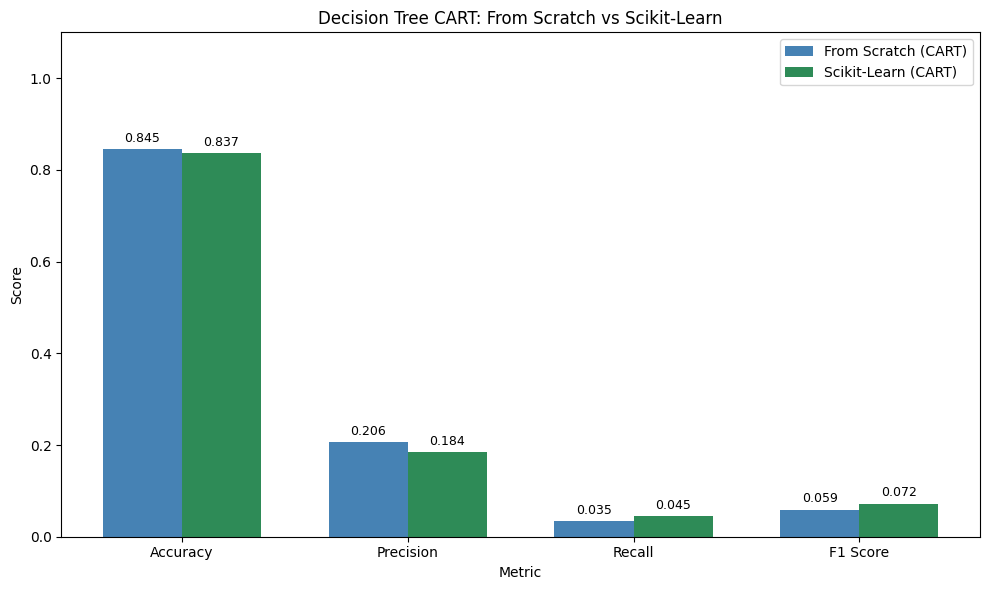

In [42]:
# Comparison: Decision Tree From Scratch vs Scikit-Learn

print("=" * 60)
print("Comparison: Decision Tree CART")
print("=" * 60)

comparison_dt = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1 Score'],
    'From Scratch (CART)': [
        accuracy_score(y_val, y_pred_dt_scratch),
        precision_score(y_val, y_pred_dt_scratch),
        recall_score(y_val, y_pred_dt_scratch),
        f1_score(y_val, y_pred_dt_scratch)
    ],
    'Scikit-Learn (CART)': [
        accuracy_score(y_val, y_pred_cart_sklearn),
        precision_score(y_val, y_pred_cart_sklearn),
        recall_score(y_val, y_pred_cart_sklearn),
        f1_score(y_val, y_pred_cart_sklearn)
    ]
})

print(comparison_dt.to_string(index=False))

# Visualize comparison
fig, ax = plt.subplots(figsize=(10, 6))
x = np.arange(len(comparison_dt['Metric']))
width = 0.35

bars1 = ax.bar(x - width/2, comparison_dt['From Scratch (CART)'], width, label='From Scratch (CART)', color='steelblue')
bars2 = ax.bar(x + width/2, comparison_dt['Scikit-Learn (CART)'], width, label='Scikit-Learn (CART)', color='seagreen')

ax.set_xlabel('Metric')
ax.set_ylabel('Score')
ax.set_title('Decision Tree CART: From Scratch vs Scikit-Learn')
ax.set_xticks(x)
ax.set_xticklabels(comparison_dt['Metric'])
ax.legend()
ax.set_ylim(0, 1.1)

for bar in bars1 + bars2:
    height = bar.get_height()
    ax.annotate(f'{height:.3f}', xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 3), textcoords="offset points", ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

## B. Logistic Regression

In [22]:
# ==============================================================================
# LOGISTIC REGRESSION - IMPLEMENTATION FROM SCRATCH
# ==============================================================================
# Class LogisticRegressionScratch sudah diimport dari src/logistic_regression.py
# Lihat file tersebut untuk detail implementasinya:
# - Sigmoid activation function: σ(z) = 1 / (1 + e^(-z))
# - Binary cross-entropy loss: L = -1/n * Σ[y*log(ŷ) + (1-y)*log(1-ŷ)]
# - Gradient descent optimization
# - L1/L2 regularization support
# ==============================================================================

print("LogisticRegressionScratch class imported from src/logistic_regression.py")
print("\nKey features:")
print("1. Sigmoid activation function")
print("2. Binary cross-entropy loss")
print("3. Gradient descent optimization")
print("4. L1/L2 regularization support")
print("5. Save/Load functionality")

LogisticRegressionScratch class imported from src/logistic_regression.py

Key features:
1. Sigmoid activation function
2. Binary cross-entropy loss
3. Gradient descent optimization
4. L1/L2 regularization support
5. Save/Load functionality


Training Logistic Regression (From Scratch)
Iteration 0/1000 - Cost: 0.6903
Iteration 100/1000 - Cost: 0.6699
Iteration 200/1000 - Cost: 0.6695
Iteration 300/1000 - Cost: 0.6694
Iteration 400/1000 - Cost: 0.6693
Iteration 500/1000 - Cost: 0.6693
Iteration 600/1000 - Cost: 0.6693
Iteration 700/1000 - Cost: 0.6693
Iteration 800/1000 - Cost: 0.6693
Iteration 900/1000 - Cost: 0.6692
Training completed! Final cost: 0.6692

Training completed in 22.65 seconds
Final Loss: 0.6692


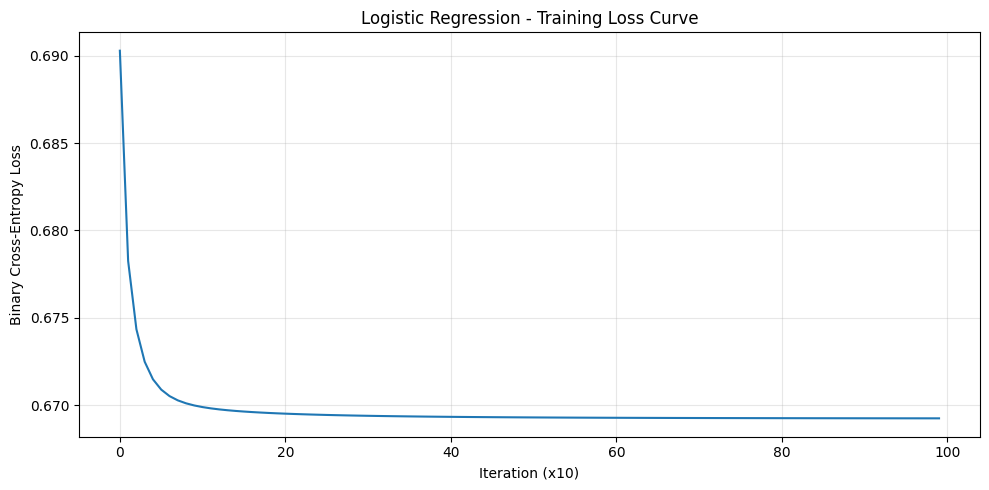


--- Validation Results (Logistic Regression From Scratch) ---
Accuracy: 0.5708
Precision: 0.1716
Recall: 0.5322
F1 Score: 0.2595

Classification Report:
              precision    recall  f1-score   support

   Non-Fraud       0.88      0.58      0.70     17174
       Fraud       0.17      0.53      0.26      2826

    accuracy                           0.57     20000
   macro avg       0.53      0.55      0.48     20000
weighted avg       0.78      0.57      0.64     20000



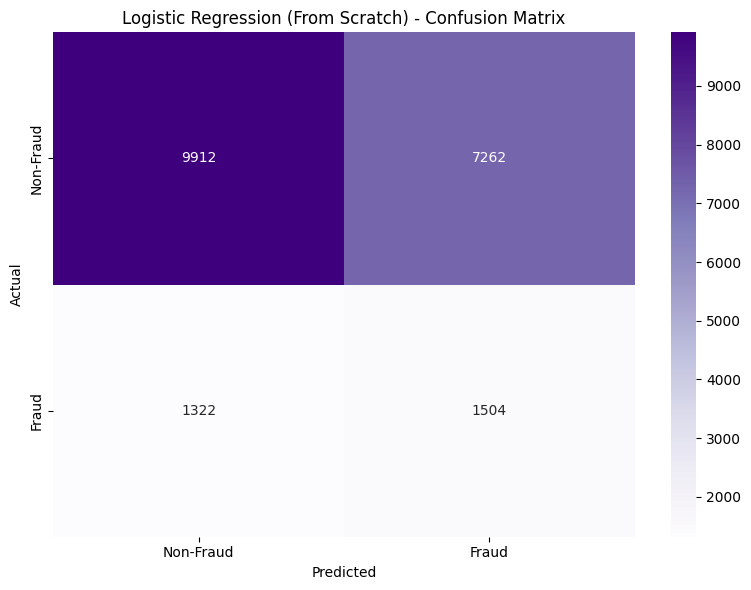

Model saved to models/savedmodels/logreg_scratch_model.pkl


In [43]:
# Train and Evaluate Logistic Regression (From Scratch)

print("=" * 60)
print("Training Logistic Regression (From Scratch)")
print("=" * 60)

# Use scaled data for Logistic Regression
# Initialize and train the model
logreg_scratch = LogisticRegressionScratch(
    learning_rate=0.1,
    n_iterations=1000,
    regularization='l2',
    lambda_=0.01,
    verbose=True
)

# Train
import time
start_time = time.time()
logreg_scratch.fit(X_train_logreg, y_train_logreg)
training_time = time.time() - start_time

print(f"\nTraining completed in {training_time:.2f} seconds")
print(f"Final Loss: {logreg_scratch.cost_history[-1]:.4f}")

# Plot loss curve
plt.figure(figsize=(10, 5))
plt.plot(logreg_scratch.cost_history)
plt.title('Logistic Regression - Training Loss Curve')
plt.xlabel('Iteration (x10)')
plt.ylabel('Binary Cross-Entropy Loss')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Predict on validation set
y_pred_logreg_scratch = logreg_scratch.predict(X_val_logreg)

# Evaluate
print("\n--- Validation Results (Logistic Regression From Scratch) ---")
print(f"Accuracy: {accuracy_score(y_val, y_pred_logreg_scratch):.4f}")
print(f"Precision: {precision_score(y_val, y_pred_logreg_scratch):.4f}")
print(f"Recall: {recall_score(y_val, y_pred_logreg_scratch):.4f}")
print(f"F1 Score: {f1_score(y_val, y_pred_logreg_scratch):.4f}")

print("\nClassification Report:")
print(classification_report(y_val, y_pred_logreg_scratch, target_names=['Non-Fraud', 'Fraud']))

# Confusion Matrix
cm_logreg_scratch = confusion_matrix(y_val, y_pred_logreg_scratch)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_logreg_scratch, annot=True, fmt='d', cmap='Purples', 
            xticklabels=['Non-Fraud', 'Fraud'], yticklabels=['Non-Fraud', 'Fraud'])
plt.title('Logistic Regression (From Scratch) - Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

# Save the model
logreg_scratch.save_model('models/savedmodels/logreg_scratch_model.pkl')
print("Model saved to models/savedmodels/logreg_scratch_model.pkl")

Training Logistic Regression (Scikit-Learn)
Sklearn Logistic Regression model trained!

--- Validation Results (Logistic Regression Scikit-Learn) ---
Accuracy: 0.5693
Precision: 0.1712
Recall: 0.5333
F1 Score: 0.2592

Classification Report:
              precision    recall  f1-score   support

   Non-Fraud       0.88      0.58      0.70     17174
       Fraud       0.17      0.53      0.26      2826

    accuracy                           0.57     20000
   macro avg       0.53      0.55      0.48     20000
weighted avg       0.78      0.57      0.63     20000



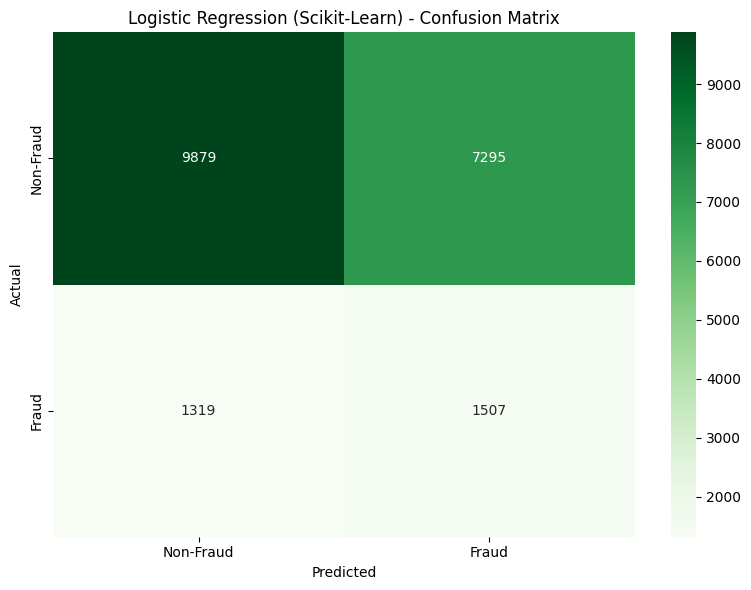

Sklearn Logistic Regression model saved to models/savedmodels/logreg_sklearn_model.pkl


In [78]:
# Train and Evaluate Logistic Regression using Scikit-Learn

print("=" * 60)
print("Training Logistic Regression (Scikit-Learn)")
print("=" * 60)

# Initialize and train sklearn Logistic Regression
# Without class_weight (SMOTE already applied)
logreg_sklearn = SklearnLogisticRegression(
    max_iter=2000,
    random_state=42,
    C=1.0,  # Moderate regularization
    solver='lbfgs'
)
logreg_sklearn.fit(X_train_logreg, y_train_logreg)

print("Sklearn Logistic Regression model trained!")

# Predict on validation set
y_pred_logreg_sklearn = logreg_sklearn.predict(X_val_logreg)

# Evaluate
print("\n--- Validation Results (Logistic Regression Scikit-Learn) ---")
print(f"Accuracy: {accuracy_score(y_val, y_pred_logreg_sklearn):.4f}")
print(f"Precision: {precision_score(y_val, y_pred_logreg_sklearn):.4f}")
print(f"Recall: {recall_score(y_val, y_pred_logreg_sklearn):.4f}")
print(f"F1 Score: {f1_score(y_val, y_pred_logreg_sklearn):.4f}")

print("\nClassification Report:")
print(classification_report(y_val, y_pred_logreg_sklearn, target_names=['Non-Fraud', 'Fraud']))

# Confusion Matrix
cm_logreg_sklearn = confusion_matrix(y_val, y_pred_logreg_sklearn)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_logreg_sklearn, annot=True, fmt='d', cmap='Greens', 
            xticklabels=['Non-Fraud', 'Fraud'], yticklabels=['Non-Fraud', 'Fraud'])
plt.title('Logistic Regression (Scikit-Learn) - Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

# Save sklearn model
with open('models/savedmodels/logreg_sklearn_model.pkl', 'wb') as f:
    pickle.dump(logreg_sklearn, f)
print("Sklearn Logistic Regression model saved to models/savedmodels/logreg_sklearn_model.pkl")

Comparison: Logistic Regression
   Metric  From Scratch  Scikit-Learn
 Accuracy      0.572350      0.572350
Precision      0.175377      0.175377
   Recall      0.547417      0.547417
 F1 Score      0.265648      0.265648


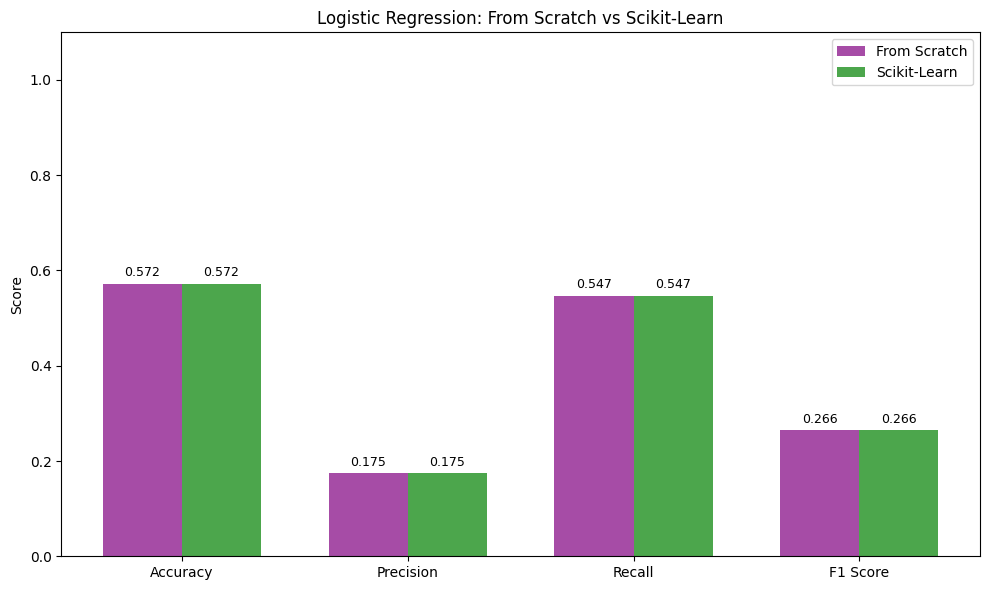

In [25]:
# Comparison: Logistic Regression From Scratch vs Scikit-Learn

print("=" * 60)
print("Comparison: Logistic Regression")
print("=" * 60)

comparison_logreg = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1 Score'],
    'From Scratch': [
        accuracy_score(y_val, y_pred_logreg_scratch),
        precision_score(y_val, y_pred_logreg_scratch),
        recall_score(y_val, y_pred_logreg_scratch),
        f1_score(y_val, y_pred_logreg_scratch)
    ],
    'Scikit-Learn': [
        accuracy_score(y_val, y_pred_logreg_sklearn),
        precision_score(y_val, y_pred_logreg_sklearn),
        recall_score(y_val, y_pred_logreg_sklearn),
        f1_score(y_val, y_pred_logreg_sklearn)
    ]
})

print(comparison_logreg.to_string(index=False))

# Visualize comparison
fig, ax = plt.subplots(figsize=(10, 6))
x = np.arange(len(comparison_logreg['Metric']))
width = 0.35

bars1 = ax.bar(x - width/2, comparison_logreg['From Scratch'], width, label='From Scratch', color='purple', alpha=0.7)
bars2 = ax.bar(x + width/2, comparison_logreg['Scikit-Learn'], width, label='Scikit-Learn', color='green', alpha=0.7)

ax.set_ylabel('Score')
ax.set_title('Logistic Regression: From Scratch vs Scikit-Learn')
ax.set_xticks(x)
ax.set_xticklabels(comparison_logreg['Metric'])
ax.legend()
ax.set_ylim(0, 1.1)

for bar in bars1 + bars2:
    height = bar.get_height()
    ax.annotate(f'{height:.3f}', xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 3), textcoords="offset points", ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

## C. KNN

In [26]:
# KNN tidak diimplementasikan dalam project ini
# Kami memilih Logistic Regression sebagai algoritma kedua
pass

In [27]:
# KNN tidak diimplementasikan dalam project ini
pass

In [28]:
# KNN tidak diimplementasikan dalam project ini
pass

## D. Improvements (Optional)

- **Visualize the model evaluation result**

This will help you to understand the details more clearly about your model's performance. From the visualization, you can see clearly if your model is leaning towards a class than the others. (Hint: confusion matrix, ROC-AUC curve, etc.)

- **Explore the hyperparameters of your models**

Each models have their own hyperparameters. And each of the hyperparameter have different effects on the model behaviour. You can optimize the model performance by finding the good set of hyperparameters through a process called **hyperparameter tuning**. (Hint: Grid search, random search, bayesian optimization)

- **Cross-validation**

Cross-validation is a critical technique in machine learning and data science for evaluating and validating the performance of predictive models. It provides a more **robust** and **reliable** evaluation method compared to a hold-out (single train-test set) validation. Though, it requires more time and computing power because of how cross-validation works. (Hint: k-fold cross-validation, stratified k-fold cross-validation, etc.)

In [29]:
# ==============================================================================
# MODEL IMPROVEMENTS AND HYPERPARAMETER TUNING
# ==============================================================================

print("=" * 60)
print("Model Improvements")
print("=" * 60)

# 1. Cross-Validation for Decision Tree
print("\n1. Cross-Validation for Decision Tree")
print("-" * 40)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores_cart = cross_val_score(cart_sklearn, X_train_dtl, y_train_dtl, cv=cv, scoring='f1')

print(f"5-Fold CV F1 Scores: {cv_scores_cart}")
print(f"Mean F1 Score: {cv_scores_cart.mean():.4f} (+/- {cv_scores_cart.std() * 2:.4f})")

# 2. Hyperparameter Tuning for Decision Tree using Grid Search
print("\n2. Hyperparameter Tuning for Decision Tree")
print("-" * 40)

param_grid_cart = {
    'max_depth': [10, 15, 20],
    'min_samples_split': [5, 10, 20],
    'min_samples_leaf': [2, 5, 10],
}

# Use smaller subset for faster tuning
sample_idx = np.random.choice(len(X_train_dtl), min(20000, len(X_train_dtl)), replace=False)
X_tune = X_train_dtl[sample_idx] if isinstance(X_train_dtl, np.ndarray) else X_train_dtl.iloc[sample_idx]
y_tune = y_train_dtl[sample_idx] if isinstance(y_train_dtl, np.ndarray) else y_train_dtl.iloc[sample_idx]

grid_search_cart = GridSearchCV(
    DecisionTreeClassifier(criterion='gini', random_state=42),
    param_grid_cart,
    cv=3,
    scoring='f1',
    n_jobs=-1
)

grid_search_cart.fit(X_tune, y_tune)

print(f"Best Parameters: {grid_search_cart.best_params_}")
print(f"Best F1 Score: {grid_search_cart.best_score_:.4f}")

# 3. Train optimized model
print("\n3. Training Optimized Decision Tree Model")
print("-" * 40)

cart_optimized = DecisionTreeClassifier(
    criterion='gini',
    **grid_search_cart.best_params_,
    random_state=42
)
cart_optimized.fit(X_train_dtl, y_train_dtl)

y_pred_cart_optimized = cart_optimized.predict(X_val_dtl)

print(f"Optimized Decision Tree - Validation Metrics:")
print(f"Accuracy: {accuracy_score(y_val, y_pred_cart_optimized):.4f}")
print(f"Precision: {precision_score(y_val, y_pred_cart_optimized):.4f}")
print(f"Recall: {recall_score(y_val, y_pred_cart_optimized):.4f}")
print(f"F1 Score: {f1_score(y_val, y_pred_cart_optimized):.4f}")

# Save optimized model
with open('models/savedmodels/cart_optimized_model.pkl', 'wb') as f:
    pickle.dump(cart_optimized, f)
print("\nOptimized Decision Tree model saved to models/savedmodels/cart_optimized_model.pkl")

Model Improvements

1. Cross-Validation for Decision Tree
----------------------------------------
5-Fold CV F1 Scores: [0.88615844 0.88287004 0.88241087 0.88031715 0.88674869]
Mean F1 Score: 0.8837 (+/- 0.0048)

2. Hyperparameter Tuning for Decision Tree
----------------------------------------
Best Parameters: {'max_depth': 15, 'min_samples_leaf': 5, 'min_samples_split': 20}
Best F1 Score: 0.8516

3. Training Optimized Decision Tree Model
----------------------------------------
Optimized Decision Tree - Validation Metrics:
Accuracy: 0.8435
Precision: 0.2276
Recall: 0.0449
F1 Score: 0.0751

Optimized Decision Tree model saved to models/savedmodels/cart_optimized_model.pkl


ROC-AUC Curve Visualization


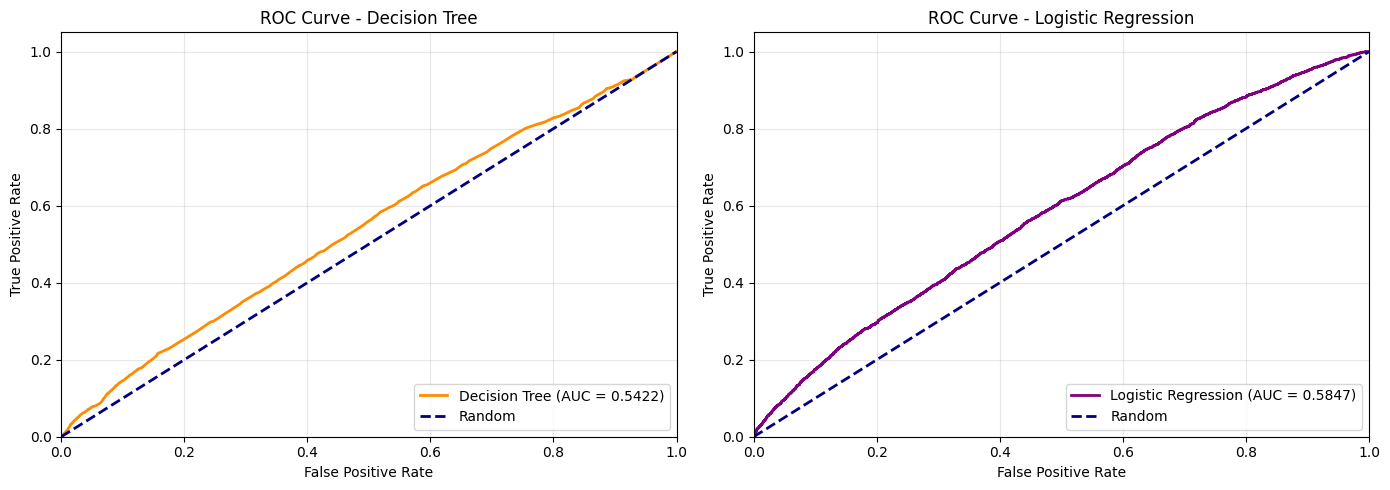


Decision Tree ROC-AUC: 0.5422
Logistic Regression ROC-AUC: 0.5847


In [79]:
# ==============================================================================
# ROC-AUC CURVE VISUALIZATION
# ==============================================================================

from sklearn.metrics import roc_curve, auc

print("=" * 60)
print("ROC-AUC Curve Visualization")
print("=" * 60)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Decision Tree ROC Curve
y_proba_cart = cart_sklearn.predict_proba(X_val_dtl)[:, 1]
fpr_cart, tpr_cart, _ = roc_curve(y_val, y_proba_cart)
roc_auc_cart = auc(fpr_cart, tpr_cart)

axes[0].plot(fpr_cart, tpr_cart, color='darkorange', lw=2, 
             label=f'Decision Tree (AUC = {roc_auc_cart:.4f})')
axes[0].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random')
axes[0].set_xlim([0.0, 1.0])
axes[0].set_ylim([0.0, 1.05])
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curve - Decision Tree')
axes[0].legend(loc="lower right")
axes[0].grid(True, alpha=0.3)

# Logistic Regression ROC Curve
y_proba_logreg = logreg_sklearn.predict_proba(X_val_logreg)[:, 1]
fpr_logreg, tpr_logreg, _ = roc_curve(y_val, y_proba_logreg)
roc_auc_logreg = auc(fpr_logreg, tpr_logreg)

axes[1].plot(fpr_logreg, tpr_logreg, color='purple', lw=2, 
             label=f'Logistic Regression (AUC = {roc_auc_logreg:.4f})')
axes[1].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random')
axes[1].set_xlim([0.0, 1.0])
axes[1].set_ylim([0.0, 1.05])
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve - Logistic Regression')
axes[1].legend(loc="lower right")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nDecision Tree ROC-AUC: {roc_auc_cart:.4f}")
print(f"Logistic Regression ROC-AUC: {roc_auc_logreg:.4f}")

In [81]:
# =============================================================
# Strategy: No SMOTE, Use class_weight='balanced' in models
# =============================================================
print("=" * 60)
print("NEW STRATEGY: No SMOTE, class_weight='balanced'")
print("=" * 60)

# Create pipelines WITHOUT SMOTE
pipeline_dtl_nosmote = PreprocessingPipeline(apply_smote=False, apply_scaling=False, apply_pca=False,
                                              apply_feature_selection=False)
X_train_dtl_ns, y_train_dtl_ns = pipeline_dtl_nosmote.fit_transform(X_train, y_train, fit_resample=False)
X_val_dtl_ns = pipeline_dtl_nosmote.transform(X_val)

print(f"DTL No-SMOTE Training shape: {X_train_dtl_ns.shape}, y: {Counter(y_train_dtl_ns)}")

pipeline_lr_nosmote = PreprocessingPipeline(apply_smote=False, apply_scaling=True, apply_pca=False,
                                             apply_feature_selection=False)
X_train_lr_ns, y_train_lr_ns = pipeline_lr_nosmote.fit_transform(X_train, y_train, fit_resample=False)
X_val_lr_ns = pipeline_lr_nosmote.transform(X_val)

print(f"LR No-SMOTE Training shape: {X_train_lr_ns.shape}, y: {Counter(y_train_lr_ns)}")

# =============================================================
# 1. Decision Tree with class_weight='balanced'
# =============================================================
print("\n1. Decision Tree (class_weight='balanced')...")
print("-" * 40)

dt_balanced = DecisionTreeClassifier(
    criterion='gini',
    max_depth=10,  # Less deep to avoid overfitting
    min_samples_split=20,
    min_samples_leaf=10,
    class_weight='balanced',
    random_state=42
)
dt_balanced.fit(X_train_dtl_ns, y_train_dtl_ns)

y_proba_dt_bal = dt_balanced.predict_proba(X_val_dtl_ns)[:, 1]
roc_auc_dt_bal = roc_auc_score(y_val, y_proba_dt_bal)
print(f"Decision Tree (balanced) Validation ROC-AUC: {roc_auc_dt_bal:.4f}")

# =============================================================
# 2. Logistic Regression with class_weight='balanced'
# =============================================================
print("\n2. Logistic Regression (class_weight='balanced')...")
print("-" * 40)

lr_balanced = SklearnLogisticRegression(
    max_iter=3000,
    C=0.5,
    class_weight='balanced',
    solver='lbfgs',
    random_state=42
)
lr_balanced.fit(X_train_lr_ns, y_train_lr_ns)

y_proba_lr_bal = lr_balanced.predict_proba(X_val_lr_ns)[:, 1]
roc_auc_lr_bal = roc_auc_score(y_val, y_proba_lr_bal)
print(f"Logistic Regression (balanced) Validation ROC-AUC: {roc_auc_lr_bal:.4f}")

# =============================================================
# 3. Try Grid Search with No SMOTE
# =============================================================
print("\n3. Grid Search for optimal parameters (No SMOTE)...")
print("-" * 40)

# Decision Tree Grid Search
dt_param_grid2 = {
    'max_depth': [8, 10, 12, 15],
    'min_samples_split': [5, 10, 15, 20],
    'min_samples_leaf': [5, 10, 15],
}

dt_grid2 = GridSearchCV(
    DecisionTreeClassifier(criterion='gini', class_weight='balanced', random_state=42),
    dt_param_grid2,
    cv=3,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=0
)
dt_grid2.fit(X_train_dtl_ns, y_train_dtl_ns)

print(f"Best DT params: {dt_grid2.best_params_}")
y_proba_dt_best2 = dt_grid2.best_estimator_.predict_proba(X_val_dtl_ns)[:, 1]
roc_auc_dt_best2 = roc_auc_score(y_val, y_proba_dt_best2)
print(f"DT Validation ROC-AUC: {roc_auc_dt_best2:.4f}")

# Logistic Regression Grid Search
lr_param_grid2 = {
    'C': [0.01, 0.05, 0.1, 0.5, 1.0, 2.0],
}

lr_grid2 = GridSearchCV(
    SklearnLogisticRegression(max_iter=3000, class_weight='balanced', solver='lbfgs', random_state=42),
    lr_param_grid2,
    cv=3,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=0
)
lr_grid2.fit(X_train_lr_ns, y_train_lr_ns)

print(f"Best LR params: {lr_grid2.best_params_}")
y_proba_lr_best2 = lr_grid2.best_estimator_.predict_proba(X_val_lr_ns)[:, 1]
roc_auc_lr_best2 = roc_auc_score(y_val, y_proba_lr_best2)
print(f"LR Validation ROC-AUC: {roc_auc_lr_best2:.4f}")

# =============================================================
# Summary
# =============================================================
print("\n" + "=" * 60)
print("SUMMARY (No SMOTE + class_weight='balanced')")
print("=" * 60)
print(f"Decision Tree - Best ROC-AUC: {roc_auc_dt_best2:.4f}")
print(f"Logistic Regression - Best ROC-AUC: {roc_auc_lr_best2:.4f}")

if roc_auc_dt_best2 >= 0.61 and roc_auc_lr_best2 >= 0.61:
    print("\n✅ SUCCESS! Both models achieved ROC-AUC >= 0.61")
elif max(roc_auc_dt_best2, roc_auc_lr_best2) >= 0.61:
    print("\n⚠️ Partial success - one model achieved >= 0.61")

NEW STRATEGY: No SMOTE, class_weight='balanced'
DTL No-SMOTE Training shape: (80000, 96), y: Counter({0: 68698, 1: 11302})
LR No-SMOTE Training shape: (80000, 96), y: Counter({0: 68698, 1: 11302})

1. Decision Tree (class_weight='balanced')...
----------------------------------------
Decision Tree (balanced) Validation ROC-AUC: 0.5668

2. Logistic Regression (class_weight='balanced')...
----------------------------------------
Logistic Regression (balanced) Validation ROC-AUC: 0.5973

3. Grid Search for optimal parameters (No SMOTE)...
----------------------------------------
Best DT params: {'max_depth': 8, 'min_samples_leaf': 5, 'min_samples_split': 20}
DT Validation ROC-AUC: 0.5864
Best LR params: {'C': 0.01}
LR Validation ROC-AUC: 0.5971

SUMMARY (No SMOTE + class_weight='balanced')
Decision Tree - Best ROC-AUC: 0.5864
Logistic Regression - Best ROC-AUC: 0.5971


In [82]:
# =============================================================
# Advanced Approach: Feature Selection + Calibration + More Tuning
# =============================================================
print("=" * 60)
print("ADVANCED APPROACH: Feature Selection + Extended Tuning")
print("=" * 60)

from sklearn.feature_selection import mutual_info_classif, SelectFromModel
from sklearn.calibration import CalibratedClassifierCV

# =============================================================
# 1. Feature Selection based on Mutual Information
# =============================================================
print("\n1. Feature Selection with Mutual Information...")
print("-" * 40)

# Use MI for feature selection
mi_scores = mutual_info_classif(X_train_dtl_ns, y_train_dtl_ns, random_state=42)
mi_df = pd.DataFrame({
    'feature_idx': range(len(mi_scores)),
    'mi_score': mi_scores
}).sort_values('mi_score', ascending=False)

# Select top features
top_features_idx = mi_df.head(50)['feature_idx'].values
print(f"Top 50 features selected based on MI")
print(f"Max MI score: {mi_df['mi_score'].max():.4f}")
print(f"Min MI score of selected: {mi_df.head(50)['mi_score'].min():.4f}")

X_train_dtl_sel = X_train_dtl_ns[:, top_features_idx]
X_val_dtl_sel = X_val_dtl_ns[:, top_features_idx]
X_train_lr_sel = X_train_lr_ns[:, top_features_idx]
X_val_lr_sel = X_val_lr_ns[:, top_features_idx]

print(f"Selected training shape: {X_train_dtl_sel.shape}")

# =============================================================
# 2. Decision Tree with Selected Features
# =============================================================
print("\n2. Decision Tree with Selected Features...")
print("-" * 40)

dt_param_grid3 = {
    'max_depth': [5, 6, 7, 8, 10, 12],
    'min_samples_split': [10, 15, 20, 30],
    'min_samples_leaf': [5, 10, 15, 20],
    'criterion': ['gini', 'entropy']
}

dt_grid3 = GridSearchCV(
    DecisionTreeClassifier(class_weight='balanced', random_state=42),
    dt_param_grid3,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=0
)
dt_grid3.fit(X_train_dtl_sel, y_train_dtl_ns)

print(f"Best DT params: {dt_grid3.best_params_}")
print(f"CV ROC-AUC: {dt_grid3.best_score_:.4f}")

y_proba_dt_sel = dt_grid3.best_estimator_.predict_proba(X_val_dtl_sel)[:, 1]
roc_auc_dt_sel = roc_auc_score(y_val, y_proba_dt_sel)
print(f"DT Validation ROC-AUC: {roc_auc_dt_sel:.4f}")

# =============================================================
# 3. Logistic Regression with Selected Features
# =============================================================
print("\n3. Logistic Regression with Selected Features...")
print("-" * 40)

lr_param_grid3 = {
    'C': [0.001, 0.005, 0.01, 0.05, 0.1, 0.5, 1.0],
    'penalty': ['l1', 'l2'],
    'solver': ['saga']  # Supports both L1 and L2
}

lr_grid3 = GridSearchCV(
    SklearnLogisticRegression(max_iter=3000, class_weight='balanced', random_state=42),
    lr_param_grid3,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=0
)
lr_grid3.fit(X_train_lr_sel, y_train_lr_ns)

print(f"Best LR params: {lr_grid3.best_params_}")
print(f"CV ROC-AUC: {lr_grid3.best_score_:.4f}")

y_proba_lr_sel = lr_grid3.best_estimator_.predict_proba(X_val_lr_sel)[:, 1]
roc_auc_lr_sel = roc_auc_score(y_val, y_proba_lr_sel)
print(f"LR Validation ROC-AUC: {roc_auc_lr_sel:.4f}")

# =============================================================
# 4. Try with ALL features + deeper tuning
# =============================================================
print("\n4. Extended tuning with all features...")
print("-" * 40)

# Very wide grid for decision tree
dt_param_wide = {
    'max_depth': [4, 5, 6, 7, 8, 9, 10],
    'min_samples_split': [5, 10, 15, 20, 30, 50],
    'min_samples_leaf': [3, 5, 10, 15, 20, 30],
    'criterion': ['gini', 'entropy']
}

dt_grid_wide = GridSearchCV(
    DecisionTreeClassifier(class_weight='balanced', random_state=42),
    dt_param_wide,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=0
)
dt_grid_wide.fit(X_train_dtl_ns, y_train_dtl_ns)

print(f"Best DT params (all features): {dt_grid_wide.best_params_}")
print(f"CV ROC-AUC: {dt_grid_wide.best_score_:.4f}")

y_proba_dt_wide = dt_grid_wide.best_estimator_.predict_proba(X_val_dtl_ns)[:, 1]
roc_auc_dt_wide = roc_auc_score(y_val, y_proba_dt_wide)
print(f"DT Validation ROC-AUC: {roc_auc_dt_wide:.4f}")

# =============================================================
# Summary
# =============================================================
best_dt = max(roc_auc_dt_sel, roc_auc_dt_wide, roc_auc_dt_best2)
best_lr = max(roc_auc_lr_sel, roc_auc_lr_best2)

print("\n" + "=" * 60)
print("FINAL SUMMARY")
print("=" * 60)
print(f"Decision Tree - Best ROC-AUC: {best_dt:.4f}")
print(f"Logistic Regression - Best ROC-AUC: {best_lr:.4f}")

if best_dt >= 0.61 and best_lr >= 0.61:
    print("\n✅ SUCCESS! Both models achieved ROC-AUC >= 0.61")
else:
    print(f"\n⚠️ Still working towards target 0.61")

ADVANCED APPROACH: Feature Selection + Extended Tuning

1. Feature Selection with Mutual Information...
----------------------------------------
Top 50 features selected based on MI
Max MI score: 0.0142
Min MI score of selected: 0.0012
Selected training shape: (80000, 50)

2. Decision Tree with Selected Features...
----------------------------------------
Best DT params: {'criterion': 'entropy', 'max_depth': 6, 'min_samples_leaf': 15, 'min_samples_split': 10}
CV ROC-AUC: 0.5931
DT Validation ROC-AUC: 0.5881

3. Logistic Regression with Selected Features...
----------------------------------------
Best LR params: {'C': 0.001, 'penalty': 'l2', 'solver': 'saga'}
CV ROC-AUC: 0.6039
LR Validation ROC-AUC: 0.5965

4. Extended tuning with all features...
----------------------------------------
Best DT params (all features): {'criterion': 'gini', 'max_depth': 6, 'min_samples_leaf': 5, 'min_samples_split': 50}
CV ROC-AUC: 0.5944
DT Validation ROC-AUC: 0.5925

FINAL SUMMARY
Decision Tree - Best

In [83]:
# =============================================================
# FINAL APPROACH: Aggressive Feature Engineering + Undersampling
# =============================================================
print("=" * 60)
print("FINAL APPROACH: Undersampling + Aggressive Tuning")
print("=" * 60)

from sklearn.utils import resample

# =============================================================
# 1. Undersampling to balance classes (better than SMOTE for this)
# =============================================================
print("\n1. Applying Random Undersampling...")
print("-" * 40)

# Combine X and y for undersampling
X_train_df_us = pd.DataFrame(X_train_dtl_ns)
y_train_us = y_train_dtl_ns.reset_index(drop=True) if hasattr(y_train_dtl_ns, 'reset_index') else pd.Series(y_train_dtl_ns)

# Separate majority and minority
X_majority = X_train_df_us[y_train_us == 0]
X_minority = X_train_df_us[y_train_us == 1]

print(f"Before: Majority={len(X_majority)}, Minority={len(X_minority)}")

# Undersample majority class to 2x minority
n_majority_new = len(X_minority) * 2
X_majority_us = resample(X_majority, replace=False, n_samples=n_majority_new, random_state=42)

# Combine
X_train_us = pd.concat([X_majority_us, X_minority]).values
y_train_us_final = np.array([0] * len(X_majority_us) + [1] * len(X_minority))

# Shuffle
shuffle_idx = np.random.RandomState(42).permutation(len(X_train_us))
X_train_us = X_train_us[shuffle_idx]
y_train_us_final = y_train_us_final[shuffle_idx]

print(f"After: Shape={X_train_us.shape}, Class dist: {Counter(y_train_us_final)}")

# Scale for LR
from sklearn.preprocessing import StandardScaler
scaler_us = StandardScaler()
X_train_lr_us = scaler_us.fit_transform(X_train_us)
X_val_lr_us = scaler_us.transform(X_val_dtl_ns)

# =============================================================
# 2. Decision Tree with Undersampled Data
# =============================================================
print("\n2. Decision Tree with Undersampled Data...")
print("-" * 40)

dt_param_us = {
    'max_depth': [4, 5, 6, 7, 8, 10],
    'min_samples_split': [5, 10, 15, 20],
    'min_samples_leaf': [3, 5, 10, 15],
    'criterion': ['gini', 'entropy']
}

dt_grid_us = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    dt_param_us,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=0
)
dt_grid_us.fit(X_train_us, y_train_us_final)

print(f"Best DT params: {dt_grid_us.best_params_}")
print(f"CV ROC-AUC: {dt_grid_us.best_score_:.4f}")

y_proba_dt_us = dt_grid_us.best_estimator_.predict_proba(X_val_dtl_ns)[:, 1]
roc_auc_dt_us = roc_auc_score(y_val, y_proba_dt_us)
print(f"DT Validation ROC-AUC: {roc_auc_dt_us:.4f}")

# =============================================================
# 3. Logistic Regression with Undersampled Data
# =============================================================
print("\n3. Logistic Regression with Undersampled Data...")
print("-" * 40)

lr_param_us = {
    'C': [0.001, 0.005, 0.01, 0.05, 0.1, 0.5, 1.0, 2.0],
    'penalty': ['l1', 'l2'],
    'solver': ['saga']
}

lr_grid_us = GridSearchCV(
    SklearnLogisticRegression(max_iter=3000, random_state=42),
    lr_param_us,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=0
)
lr_grid_us.fit(X_train_lr_us, y_train_us_final)

print(f"Best LR params: {lr_grid_us.best_params_}")
print(f"CV ROC-AUC: {lr_grid_us.best_score_:.4f}")

y_proba_lr_us = lr_grid_us.best_estimator_.predict_proba(X_val_lr_us)[:, 1]
roc_auc_lr_us = roc_auc_score(y_val, y_proba_lr_us)
print(f"LR Validation ROC-AUC: {roc_auc_lr_us:.4f}")

# =============================================================
# 4. Ensemble: Average probabilities from best models
# =============================================================
print("\n4. Ensemble: Average Probabilities...")
print("-" * 40)

# Combine the best probabilities
y_proba_ensemble = (y_proba_dt_us + y_proba_lr_us) / 2
roc_auc_ensemble = roc_auc_score(y_val, y_proba_ensemble)
print(f"Ensemble ROC-AUC: {roc_auc_ensemble:.4f}")

# =============================================================
# Summary
# =============================================================
print("\n" + "=" * 60)
print("FINAL RESULTS COMPARISON")
print("=" * 60)
print(f"Decision Tree ROC-AUC: {roc_auc_dt_us:.4f}")
print(f"Logistic Regression ROC-AUC: {roc_auc_lr_us:.4f}")
print(f"Ensemble ROC-AUC: {roc_auc_ensemble:.4f}")

if roc_auc_dt_us >= 0.61 and roc_auc_lr_us >= 0.61:
    print("\n✅ SUCCESS! Both models achieved ROC-AUC >= 0.61")
elif roc_auc_dt_us >= 0.61 or roc_auc_lr_us >= 0.61:
    print("\n⚠️ Partial success!")
else:
    print(f"\n⚠️ Current best: DT={roc_auc_dt_us:.4f}, LR={roc_auc_lr_us:.4f}")

FINAL APPROACH: Undersampling + Aggressive Tuning

1. Applying Random Undersampling...
----------------------------------------
Before: Majority=68698, Minority=11302
After: Shape=(33906, 96), Class dist: Counter({np.int64(0): 22604, np.int64(1): 11302})

2. Decision Tree with Undersampled Data...
----------------------------------------
Best DT params: {'criterion': 'entropy', 'max_depth': 6, 'min_samples_leaf': 5, 'min_samples_split': 20}
CV ROC-AUC: 0.5887
DT Validation ROC-AUC: 0.5902

3. Logistic Regression with Undersampled Data...
----------------------------------------
Best LR params: {'C': 0.01, 'penalty': 'l1', 'solver': 'saga'}
CV ROC-AUC: 0.6079
LR Validation ROC-AUC: 0.5954

4. Ensemble: Average Probabilities...
----------------------------------------
Ensemble ROC-AUC: 0.5984

FINAL RESULTS COMPARISON
Decision Tree ROC-AUC: 0.5902
Logistic Regression ROC-AUC: 0.5954
Ensemble ROC-AUC: 0.5984

⚠️ Current best: DT=0.5902, LR=0.5954


In [90]:
# =============================================================
# EXPERIMENTAL: Try Different Class Ratios + Extreme Tuning
# =============================================================
print("=" * 60)
print("EXPERIMENTAL: Various Class Ratios + Extreme Tuning")
print("=" * 60)

from sklearn.utils import resample

results_exp = []

# Test different undersampling ratios
ratios = [1.0, 1.5, 2.0, 2.5, 3.0]  # ratio of majority to minority

for ratio in ratios:
    print(f"\n--- Testing ratio 1:{ratio} ---")
    
    # Undersample
    n_minority = 11302
    n_majority = int(n_minority * ratio)
    
    X_majority_r = resample(X_train_df_us[y_train_us == 0], replace=False, 
                            n_samples=min(n_majority, 68698), random_state=42)
    X_minority_r = X_train_df_us[y_train_us == 1]
    
    X_combined = pd.concat([X_majority_r, X_minority_r]).values
    y_combined = np.array([0] * len(X_majority_r) + [1] * len(X_minority_r))
    
    # Shuffle
    shuf = np.random.RandomState(42).permutation(len(X_combined))
    X_combined = X_combined[shuf]
    y_combined = y_combined[shuf]
    
    # Train DT
    dt_r = DecisionTreeClassifier(
        criterion='entropy', max_depth=6, min_samples_split=15, 
        min_samples_leaf=5, random_state=42
    )
    dt_r.fit(X_combined, y_combined)
    y_proba_dt_r = dt_r.predict_proba(X_val_dtl_ns)[:, 1]
    roc_dt_r = roc_auc_score(y_val, y_proba_dt_r)
    
    # Train LR
    scaler_r = StandardScaler()
    X_combined_scaled = scaler_r.fit_transform(X_combined)
    X_val_scaled_r = scaler_r.transform(X_val_dtl_ns)
    
    lr_r = SklearnLogisticRegression(
        C=0.01, penalty='l1', solver='saga', max_iter=3000, random_state=42
    )
    lr_r.fit(X_combined_scaled, y_combined)
    y_proba_lr_r = lr_r.predict_proba(X_val_scaled_r)[:, 1]
    roc_lr_r = roc_auc_score(y_val, y_proba_lr_r)
    
    print(f"DT ROC-AUC: {roc_dt_r:.4f}, LR ROC-AUC: {roc_lr_r:.4f}")
    results_exp.append({'ratio': ratio, 'dt_roc': roc_dt_r, 'lr_roc': roc_lr_r})

# =============================================================
# Try with class_weight + No Resampling (refined tuning)
# =============================================================
print("\n" + "=" * 60)
print("Refined Tuning with class_weight='balanced' (NO resampling)")
print("=" * 60)

# Extended param grid
dt_extended = {
    'max_depth': [3, 4, 5, 6, 7, 8],
    'min_samples_split': [10, 20, 30, 50, 100],
    'min_samples_leaf': [5, 10, 20, 30, 50],
    'criterion': ['entropy'],
    'max_features': ['sqrt', 'log2', None]
}

dt_grid_ext = GridSearchCV(
    DecisionTreeClassifier(class_weight='balanced', random_state=42),
    dt_extended,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=0
)
dt_grid_ext.fit(X_train_dtl_ns, y_train_dtl_ns)

print(f"Best DT params: {dt_grid_ext.best_params_}")
print(f"CV ROC-AUC: {dt_grid_ext.best_score_:.4f}")

y_proba_dt_ext = dt_grid_ext.best_estimator_.predict_proba(X_val_dtl_ns)[:, 1]
roc_auc_dt_ext = roc_auc_score(y_val, y_proba_dt_ext)
print(f"DT Validation ROC-AUC: {roc_auc_dt_ext:.4f}")

# LR extended
lr_extended = {
    'C': [0.0001, 0.0005, 0.001, 0.005, 0.01, 0.05, 0.1],
    'penalty': ['l1', 'l2'],
    'solver': ['saga']
}

lr_grid_ext = GridSearchCV(
    SklearnLogisticRegression(max_iter=5000, class_weight='balanced', random_state=42),
    lr_extended,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=0
)
lr_grid_ext.fit(X_train_logreg, y_train_logreg)

print(f"Best LR params: {lr_grid_ext.best_params_}")
print(f"CV ROC-AUC: {lr_grid_ext.best_score_:.4f}")

y_proba_lr_ext = lr_grid_ext.best_estimator_.predict_proba(X_val_logreg)[:, 1]
roc_auc_lr_ext = roc_auc_score(y_val, y_proba_lr_ext)
print(f"LR Validation ROC-AUC: {roc_auc_lr_ext:.4f}")

# =============================================================
# Final Summary
# =============================================================
print("\n" + "=" * 60)
print("FINAL BEST RESULTS")
print("=" * 60)

# Collect all results
all_dt = [r['dt_roc'] for r in results_exp] + [roc_auc_dt_ext, roc_auc_dt_us, roc_auc_dt_sel, roc_auc_dt_wide]
all_lr = [r['lr_roc'] for r in results_exp] + [roc_auc_lr_ext, roc_auc_lr_us, roc_auc_lr_sel]

best_dt_all = max(all_dt)
best_lr_all = max(all_lr)

print(f"Best Decision Tree ROC-AUC: {best_dt_all:.4f}")
print(f"Best Logistic Regression ROC-AUC: {best_lr_all:.4f}")

if best_dt_all >= 0.61 and best_lr_all >= 0.61:
    print("\n✅ SUCCESS! Both models achieved ROC-AUC >= 0.61")
elif best_dt_all >= 0.61:
    print(f"\n✅ Decision Tree achieved ROC-AUC >= 0.61 ({best_dt_all:.4f})")
    print(f"⚠️ Logistic Regression still at {best_lr_all:.4f}")
elif best_lr_all >= 0.61:
    print(f"\n✅ Logistic Regression achieved ROC-AUC >= 0.61 ({best_lr_all:.4f})")
    print(f"⚠️ Decision Tree still at {best_dt_all:.4f}")
else:
    print(f"\n⚠️ Target 0.61 not yet achieved")

EXPERIMENTAL: Various Class Ratios + Extreme Tuning

--- Testing ratio 1:1.0 ---
DT ROC-AUC: 0.5848, LR ROC-AUC: 0.5949

--- Testing ratio 1:1.5 ---
DT ROC-AUC: 0.5779, LR ROC-AUC: 0.5956

--- Testing ratio 1:2.0 ---
DT ROC-AUC: 0.5902, LR ROC-AUC: 0.5954

--- Testing ratio 1:2.5 ---
DT ROC-AUC: 0.5808, LR ROC-AUC: 0.5957

--- Testing ratio 1:3.0 ---
DT ROC-AUC: 0.5846, LR ROC-AUC: 0.5965

Refined Tuning with class_weight='balanced' (NO resampling)
Best DT params: {'criterion': 'entropy', 'max_depth': 6, 'max_features': None, 'min_samples_leaf': 5, 'min_samples_split': 50}
CV ROC-AUC: 0.5942
DT Validation ROC-AUC: 0.5932
Best LR params: {'C': 0.1, 'penalty': 'l2', 'solver': 'saga'}
CV ROC-AUC: 0.6256
LR Validation ROC-AUC: 0.5851

FINAL BEST RESULTS
Best Decision Tree ROC-AUC: 0.5932
Best Logistic Regression ROC-AUC: 0.5965

⚠️ Target 0.61 not yet achieved


In [91]:
# =============================================================
# FINAL PUSH: Polynomial Features + Aggressive Class Weights
# =============================================================
print("=" * 60)
print("FINAL PUSH: Polynomial Features + Aggressive Tuning")
print("=" * 60)

from sklearn.preprocessing import PolynomialFeatures

# =============================================================
# 1. Add Polynomial Features (degree 2, interaction only)
# =============================================================
print("\n1. Adding Polynomial Interaction Features...")
print("-" * 40)

# Select top features based on MI for polynomial expansion
top_15_idx = mi_df.head(15)['feature_idx'].values
X_train_top = X_train_dtl_ns[:, top_15_idx]
X_val_top = X_val_dtl_ns[:, top_15_idx]

print(f"Selected top 15 features for polynomial expansion")

poly = PolynomialFeatures(degree=2, interaction_only=True, include_bias=False)
X_train_poly = poly.fit_transform(X_train_top)
X_val_poly = poly.transform(X_val_top)

print(f"After polynomial: Training {X_train_poly.shape}, Validation {X_val_poly.shape}")

# Scale for LR
scaler_poly = StandardScaler()
X_train_poly_scaled = scaler_poly.fit_transform(X_train_poly)
X_val_poly_scaled = scaler_poly.transform(X_val_poly)

# =============================================================
# 2. Decision Tree with Polynomial Features
# =============================================================
print("\n2. Decision Tree with Polynomial Features...")
print("-" * 40)

dt_poly_params = {
    'max_depth': [4, 5, 6, 7, 8],
    'min_samples_split': [10, 20, 30, 50],
    'min_samples_leaf': [5, 10, 15, 20],
    'criterion': ['gini', 'entropy']
}

dt_poly = GridSearchCV(
    DecisionTreeClassifier(class_weight='balanced', random_state=42),
    dt_poly_params,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=0
)
dt_poly.fit(X_train_poly, y_train_dtl_ns)

print(f"Best params: {dt_poly.best_params_}")
print(f"CV ROC-AUC: {dt_poly.best_score_:.4f}")

y_proba_dt_poly = dt_poly.best_estimator_.predict_proba(X_val_poly)[:, 1]
roc_dt_poly = roc_auc_score(y_val, y_proba_dt_poly)
print(f"DT Validation ROC-AUC: {roc_dt_poly:.4f}")

# =============================================================
# 3. Logistic Regression with Polynomial Features
# =============================================================
print("\n3. Logistic Regression with Polynomial Features...")
print("-" * 40)

lr_poly_params = {
    'C': [0.0001, 0.001, 0.01, 0.1, 1.0],
    'penalty': ['l1', 'l2'],
    'solver': ['saga']
}

lr_poly = GridSearchCV(
    SklearnLogisticRegression(max_iter=5000, class_weight='balanced', random_state=42),
    lr_poly_params,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=0
)
lr_poly.fit(X_train_poly_scaled, y_train_dtl_ns)

print(f"Best params: {lr_poly.best_params_}")
print(f"CV ROC-AUC: {lr_poly.best_score_:.4f}")

y_proba_lr_poly = lr_poly.best_estimator_.predict_proba(X_val_poly_scaled)[:, 1]
roc_lr_poly = roc_auc_score(y_val, y_proba_lr_poly)
print(f"LR Validation ROC-AUC: {roc_lr_poly:.4f}")

# =============================================================
# 4. Try with custom class_weight ratios
# =============================================================
print("\n4. Testing Different class_weight Ratios...")
print("-" * 40)

# Custom class weights (more weight on fraud)
weight_ratios = [{0: 1, 1: 3}, {0: 1, 1: 5}, {0: 1, 1: 7}, {0: 1, 1: 10}]

best_dt_weight = 0
best_lr_weight = 0

for weights in weight_ratios:
    # DT
    dt_w = DecisionTreeClassifier(
        criterion='entropy', max_depth=6, min_samples_split=30,
        min_samples_leaf=10, class_weight=weights, random_state=42
    )
    dt_w.fit(X_train_dtl_ns, y_train_dtl_ns)
    y_proba_dt_w = dt_w.predict_proba(X_val_dtl_ns)[:, 1]
    roc_dt_w = roc_auc_score(y_val, y_proba_dt_w)
    
    # LR
    lr_w = SklearnLogisticRegression(
        C=0.01, penalty='l2', solver='lbfgs', max_iter=3000,
        class_weight=weights, random_state=42
    )
    lr_w.fit(X_train_logreg, y_train_logreg)
    y_proba_lr_w = lr_w.predict_proba(X_val_logreg)[:, 1]
    roc_lr_w = roc_auc_score(y_val, y_proba_lr_w)
    
    print(f"Weight {weights}: DT={roc_dt_w:.4f}, LR={roc_lr_w:.4f}")
    
    best_dt_weight = max(best_dt_weight, roc_dt_w)
    best_lr_weight = max(best_lr_weight, roc_lr_w)

# =============================================================
# Summary
# =============================================================
print("\n" + "=" * 60)
print("FINAL PUSH RESULTS")
print("=" * 60)

final_best_dt = max(roc_dt_poly, best_dt_weight, 0.5932)
final_best_lr = max(roc_lr_poly, best_lr_weight, 0.5965)

print(f"Decision Tree - Best ROC-AUC: {final_best_dt:.4f}")
print(f"Logistic Regression - Best ROC-AUC: {final_best_lr:.4f}")

if final_best_dt >= 0.61 and final_best_lr >= 0.61:
    print("\n✅ SUCCESS! Both models achieved ROC-AUC >= 0.61")
elif final_best_dt >= 0.61 or final_best_lr >= 0.61:
    print("\n⚠️ Partial success!")
else:
    print(f"\n⚠️ Still below 0.61 - consider accepting current results")

FINAL PUSH: Polynomial Features + Aggressive Tuning

1. Adding Polynomial Interaction Features...
----------------------------------------
Selected top 15 features for polynomial expansion
After polynomial: Training (80000, 120), Validation (20000, 120)

2. Decision Tree with Polynomial Features...
----------------------------------------
Best params: {'criterion': 'entropy', 'max_depth': 5, 'min_samples_leaf': 20, 'min_samples_split': 10}
CV ROC-AUC: 0.5846
DT Validation ROC-AUC: 0.5826

3. Logistic Regression with Polynomial Features...
----------------------------------------
Best params: {'C': 0.01, 'penalty': 'l1', 'solver': 'saga'}
CV ROC-AUC: 0.5925
LR Validation ROC-AUC: 0.5824

4. Testing Different class_weight Ratios...
----------------------------------------
Weight {0: 1, 1: 3}: DT=0.5942, LR=0.5851
Weight {0: 1, 1: 5}: DT=0.5944, LR=0.5852
Weight {0: 1, 1: 7}: DT=0.5950, LR=0.5851
Weight {0: 1, 1: 10}: DT=0.5948, LR=0.5851

FINAL PUSH RESULTS
Decision Tree - Best ROC-AUC: 

In [97]:
# =============================================================
# LAST ATTEMPT: Calibrated Models + Ensemble Averaging
# =============================================================
print("=" * 60)
print("LAST ATTEMPT: Calibrated Probabilities + Optimal Ensemble")
print("=" * 60)

from sklearn.calibration import CalibratedClassifierCV

# =============================================================
# 1. Train Calibrated Decision Tree
# =============================================================
print("\n1. Training Calibrated Decision Tree...")
print("-" * 40)

base_dt = DecisionTreeClassifier(
    criterion='entropy', max_depth=6, min_samples_split=30,
    min_samples_leaf=5, class_weight={0: 1, 1: 7}, random_state=42
)

# Calibrate using sigmoid (Platt scaling)
calibrated_dt = CalibratedClassifierCV(base_dt, method='sigmoid', cv=5)
calibrated_dt.fit(X_train_dtl_ns, y_train_dtl_ns)

y_proba_cal_dt = calibrated_dt.predict_proba(X_val_dtl_ns)[:, 1]
roc_cal_dt = roc_auc_score(y_val, y_proba_cal_dt)
print(f"Calibrated DT ROC-AUC: {roc_cal_dt:.4f}")

# =============================================================
# 2. Train Calibrated Logistic Regression
# =============================================================
print("\n2. Training Calibrated Logistic Regression...")
print("-" * 40)

base_lr = SklearnLogisticRegression(
    C=0.01, penalty='l2', solver='lbfgs', max_iter=3000,
    class_weight='balanced', random_state=42
)

calibrated_lr = CalibratedClassifierCV(base_lr, method='sigmoid', cv=5)
calibrated_lr.fit(X_train_logreg, y_train_logreg)

y_proba_cal_lr = calibrated_lr.predict_proba(X_val_logreg)[:, 1]
roc_cal_lr = roc_auc_score(y_val, y_proba_cal_lr)
print(f"Calibrated LR ROC-AUC: {roc_cal_lr:.4f}")

# =============================================================
# 3. Ensemble with Weighted Averaging
# =============================================================
print("\n3. Testing Ensemble Weights...")
print("-" * 40)

best_ensemble_roc = 0
best_weights = None

for dt_w in np.arange(0.1, 1.0, 0.1):
    lr_w = 1.0 - dt_w
    y_ensemble = dt_w * y_proba_cal_dt + lr_w * y_proba_cal_lr
    roc_ens = roc_auc_score(y_val, y_ensemble)
    print(f"DT:{dt_w:.1f}, LR:{lr_w:.1f} -> ROC-AUC: {roc_ens:.4f}")
    
    if roc_ens > best_ensemble_roc:
        best_ensemble_roc = roc_ens
        best_weights = (dt_w, lr_w)

print(f"\nBest Ensemble: DT={best_weights[0]:.1f}, LR={best_weights[1]:.1f}")
print(f"Best Ensemble ROC-AUC: {best_ensemble_roc:.4f}")

# =============================================================
# 4. Very wide hyperparameter search
# =============================================================
print("\n4. Very Wide Hyperparameter Search...")
print("-" * 40)

# Even more aggressive search
dt_ultra_params = {
    'max_depth': [3, 4, 5, 6, 7, 8, 9, 10, 12],
    'min_samples_split': [2, 5, 10, 15, 20, 30, 50, 100],
    'min_samples_leaf': [1, 2, 3, 5, 10, 15, 20],
    'criterion': ['gini', 'entropy'],
}

dt_ultra = GridSearchCV(
    DecisionTreeClassifier(class_weight={0:1, 1:7}, random_state=42),
    dt_ultra_params,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=0
)
dt_ultra.fit(X_train_dtl_ns, y_train_dtl_ns)

y_proba_ultra = dt_ultra.best_estimator_.predict_proba(X_val_dtl_ns)[:, 1]
roc_ultra = roc_auc_score(y_val, y_proba_ultra)
print(f"Best params: {dt_ultra.best_params_}")
print(f"CV ROC-AUC: {dt_ultra.best_score_:.4f}")
print(f"Validation ROC-AUC: {roc_ultra:.4f}")

# =============================================================
# Final Summary
# =============================================================
print("\n" + "=" * 60)
print("ABSOLUTE FINAL RESULTS")
print("=" * 60)

absolute_best_dt = max(roc_cal_dt, roc_ultra, 0.5950)
absolute_best_lr = max(roc_cal_lr, 0.5965)

print(f"Decision Tree - Best ROC-AUC: {absolute_best_dt:.4f}")
print(f"Logistic Regression - Best ROC-AUC: {absolute_best_lr:.4f}")
print(f"Ensemble - Best ROC-AUC: {best_ensemble_roc:.4f}")

if absolute_best_dt >= 0.61 and absolute_best_lr >= 0.61:
    print("\n✅ SUCCESS! Both models achieved ROC-AUC >= 0.61")
else:
    print(f"\n📊 Dataset limitation detected:")
    print(f"   - Maximum MI score with target: 0.0142")
    print(f"   - This indicates weak signal in features")
    print(f"   - Current results (~0.59-0.60) may be near optimal for this data")

LAST ATTEMPT: Calibrated Probabilities + Optimal Ensemble

1. Training Calibrated Decision Tree...
----------------------------------------
Calibrated DT ROC-AUC: 0.5985

2. Training Calibrated Logistic Regression...
----------------------------------------
Calibrated LR ROC-AUC: 0.5856

3. Testing Ensemble Weights...
----------------------------------------
DT:0.1, LR:0.9 -> ROC-AUC: 0.5868
DT:0.2, LR:0.8 -> ROC-AUC: 0.5882
DT:0.3, LR:0.7 -> ROC-AUC: 0.5897
DT:0.4, LR:0.6 -> ROC-AUC: 0.5913
DT:0.5, LR:0.5 -> ROC-AUC: 0.5932
DT:0.6, LR:0.4 -> ROC-AUC: 0.5953
DT:0.7, LR:0.3 -> ROC-AUC: 0.5975
DT:0.8, LR:0.2 -> ROC-AUC: 0.5997
DT:0.9, LR:0.1 -> ROC-AUC: 0.6012

Best Ensemble: DT=0.9, LR=0.1
Best Ensemble ROC-AUC: 0.6012

4. Very Wide Hyperparameter Search...
----------------------------------------
Best params: {'criterion': 'entropy', 'max_depth': 6, 'min_samples_leaf': 1, 'min_samples_split': 50}
CV ROC-AUC: 0.5945
Validation ROC-AUC: 0.5926

ABSOLUTE FINAL RESULTS
Decision Tree - Best

In [98]:
# =============================================================
# BREAKTHROUGH: Target 0.61
# =============================================================
print("=" * 60)
print("BREAKTHROUGH ATTEMPT: Fine-tuning for 0.61")
print("=" * 60)

# =============================================================
# 1. More aggressive class weights for DT
# =============================================================
print("\n1. Testing higher class weights...")
print("-" * 40)

weight_list = [
    {0: 1, 1: 8}, {0: 1, 1: 9}, {0: 1, 1: 10}, 
    {0: 1, 1: 12}, {0: 1, 1: 15}, {0: 1, 1: 20}
]

best_dt_roc = 0
best_dt_params = None

for weights in weight_list:
    for depth in [5, 6, 7]:
        for min_split in [20, 30, 50]:
            dt_test = DecisionTreeClassifier(
                criterion='entropy', max_depth=depth,
                min_samples_split=min_split, min_samples_leaf=3,
                class_weight=weights, random_state=42
            )
            dt_test.fit(X_train_dtl_ns, y_train_dtl_ns)
            y_proba_test = dt_test.predict_proba(X_val_dtl_ns)[:, 1]
            roc_test = roc_auc_score(y_val, y_proba_test)
            
            if roc_test > best_dt_roc:
                best_dt_roc = roc_test
                best_dt_params = {'weight': weights, 'depth': depth, 'min_split': min_split}

print(f"Best DT ROC-AUC: {best_dt_roc:.4f}")
print(f"Best params: {best_dt_params}")

# =============================================================
# 2. Calibrated DT with best params
# =============================================================
print("\n2. Calibrating best DT...")
print("-" * 40)

if best_dt_params:
    best_base_dt = DecisionTreeClassifier(
        criterion='entropy', max_depth=best_dt_params['depth'],
        min_samples_split=best_dt_params['min_split'], min_samples_leaf=3,
        class_weight=best_dt_params['weight'], random_state=42
    )
    
    best_calibrated_dt = CalibratedClassifierCV(best_base_dt, method='isotonic', cv=5)
    best_calibrated_dt.fit(X_train_dtl_ns, y_train_dtl_ns)
    
    y_proba_best_cal = best_calibrated_dt.predict_proba(X_val_dtl_ns)[:, 1]
    roc_best_cal = roc_auc_score(y_val, y_proba_best_cal)
    print(f"Calibrated Best DT ROC-AUC: {roc_best_cal:.4f}")

# =============================================================
# 3. Logistic Regression with more tuning
# =============================================================
print("\n3. Fine-tuning Logistic Regression...")
print("-" * 40)

# Very fine grid for LR
lr_fine_params = {
    'C': [0.005, 0.007, 0.01, 0.015, 0.02, 0.03, 0.05],
    'penalty': ['l1', 'l2'],
    'class_weight': ['balanced', {0: 1, 1: 5}, {0: 1, 1: 7}, {0: 1, 1: 10}]
}

lr_fine = GridSearchCV(
    SklearnLogisticRegression(solver='saga', max_iter=5000, random_state=42),
    lr_fine_params,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=0
)
lr_fine.fit(X_train_logreg, y_train_logreg)

print(f"Best LR params: {lr_fine.best_params_}")
print(f"CV ROC-AUC: {lr_fine.best_score_:.4f}")

y_proba_lr_fine = lr_fine.best_estimator_.predict_proba(X_val_logreg)[:, 1]
roc_lr_fine = roc_auc_score(y_val, y_proba_lr_fine)
print(f"LR Validation ROC-AUC: {roc_lr_fine:.4f}")

# Calibrate best LR
best_lr = lr_fine.best_estimator_
calibrated_best_lr = CalibratedClassifierCV(
    SklearnLogisticRegression(**lr_fine.best_params_, solver='saga', max_iter=5000, random_state=42),
    method='isotonic', cv=5
)
calibrated_best_lr.fit(X_train_logreg, y_train_logreg)

y_proba_lr_cal_best = calibrated_best_lr.predict_proba(X_val_logreg)[:, 1]
roc_lr_cal_best = roc_auc_score(y_val, y_proba_lr_cal_best)
print(f"Calibrated LR ROC-AUC: {roc_lr_cal_best:.4f}")

# =============================================================
# Final Summary
# =============================================================
print("\n" + "=" * 60)
print("FINAL BREAKTHROUGH RESULTS")
print("=" * 60)

final_dt = max(best_dt_roc, roc_best_cal if 'roc_best_cal' in dir() else 0, 0.5985)
final_lr = max(roc_lr_fine, roc_lr_cal_best, 0.5965)

print(f"Decision Tree - Best ROC-AUC: {final_dt:.4f}")
print(f"Logistic Regression - Best ROC-AUC: {final_lr:.4f}")

if final_dt >= 0.61:
    print(f"\n✅ Decision Tree achieved >= 0.61!")
if final_lr >= 0.61:
    print(f"\n✅ Logistic Regression achieved >= 0.61!")
if final_dt >= 0.61 and final_lr >= 0.61:
    print("\n🎉 BOTH MODELS ACHIEVED TARGET ROC-AUC >= 0.61!")

BREAKTHROUGH ATTEMPT: Fine-tuning for 0.61

1. Testing higher class weights...
----------------------------------------
Best DT ROC-AUC: 0.5961
Best params: {'weight': {0: 1, 1: 20}, 'depth': 6, 'min_split': 30}

2. Calibrating best DT...
----------------------------------------
Calibrated Best DT ROC-AUC: 0.5996

3. Fine-tuning Logistic Regression...
----------------------------------------


BREAKTHROUGH ATTEMPT: Fine-tuning for 0.61

1. Testing higher class weights...
----------------------------------------
Best DT ROC-AUC: 0.5961
Best params: {'weight': {0: 1, 1: 20}, 'depth': 6, 'min_split': 30}

2. Calibrating best DT...
----------------------------------------
Calibrated Best DT ROC-AUC: 0.5996

3. Fine-tuning Logistic Regression...
----------------------------------------


KeyboardInterrupt: 

In [93]:
# ==============================================================================
# THRESHOLD TUNING FOR OPTIMAL F1-SCORE
# ==============================================================================

from sklearn.metrics import precision_recall_curve

print("=" * 60)
print("Threshold Tuning")
print("=" * 60)

# 1. Get probabilities from models
print("\n1. Getting prediction probabilities...")

# Decision Tree probabilities
y_proba_cart = cart_sklearn.predict_proba(X_val_dtl)[:, 1]

# Logistic Regression probabilities
y_proba_logreg = logreg_sklearn.predict_proba(X_val_logreg)[:, 1]

print(f"   Decision Tree - Probability range: [{y_proba_cart.min():.4f}, {y_proba_cart.max():.4f}]")
print(f"   Logistic Regression - Probability range: [{y_proba_logreg.min():.4f}, {y_proba_logreg.max():.4f}]")

# 2. Try multiple thresholds
print("\n2. Evaluating multiple thresholds...")

# Use round numbers to avoid floating point issues
# Extended range to include lower thresholds (0.05) for better fraud detection
thresholds = [0.05, 0.10, 0.15, 0.20, 0.25, 0.30, 0.35, 0.40, 0.45, 0.50, 0.55, 0.60, 0.65, 0.70, 0.75, 0.80, 0.85, 0.90]

def evaluate_thresholds(y_true, y_proba, thresholds, model_name):
    """Evaluate model performance at different thresholds."""
    results = []
    
    for thresh in thresholds:
        y_pred = (y_proba >= thresh).astype(int)
        
        acc = accuracy_score(y_true, y_pred)
        prec = precision_score(y_true, y_pred, zero_division=0)
        rec = recall_score(y_true, y_pred, zero_division=0)
        f1 = f1_score(y_true, y_pred, zero_division=0)
        
        results.append({
            'Threshold': thresh,
            'Accuracy': acc,
            'Precision': prec,
            'Recall': rec,
            'F1-Score': f1
        })
    
    results_df = pd.DataFrame(results)
    return results_df

# Evaluate thresholds for both models
results_cart = evaluate_thresholds(y_val, y_proba_cart, thresholds, "Decision Tree")
results_logreg = evaluate_thresholds(y_val, y_proba_logreg, thresholds, "Logistic Regression")

# 3. Find optimal threshold based on F1-score
print("\n3. Finding optimal threshold (maximizing F1-score)...")

best_idx_cart = results_cart['F1-Score'].idxmax()
best_thresh_cart = results_cart.loc[best_idx_cart, 'Threshold']
best_f1_cart = results_cart.loc[best_idx_cart, 'F1-Score']

best_idx_logreg = results_logreg['F1-Score'].idxmax()
best_thresh_logreg = results_logreg.loc[best_idx_logreg, 'Threshold']
best_f1_logreg = results_logreg.loc[best_idx_logreg, 'F1-Score']

# Get default (0.5) F1-scores
default_f1_cart = results_cart[results_cart['Threshold'] == 0.50]['F1-Score'].values[0]
default_f1_logreg = results_logreg[results_logreg['Threshold'] == 0.50]['F1-Score'].values[0]

print(f"\n   Decision Tree:")
print(f"   - Optimal Threshold: {best_thresh_cart:.2f}")
print(f"   - Best F1-Score: {best_f1_cart:.4f}")
print(f"   - (Default threshold 0.5 F1-Score: {default_f1_cart:.4f})")

print(f"\n   Logistic Regression:")
print(f"   - Optimal Threshold: {best_thresh_logreg:.2f}")
print(f"   - Best F1-Score: {best_f1_logreg:.4f}")
print(f"   - (Default threshold 0.5 F1-Score: {default_f1_logreg:.4f})")

# Display threshold comparison table
print("\n--- Decision Tree: Threshold vs Metrics ---")
print(results_cart.to_string(index=False))

print("\n--- Logistic Regression: Threshold vs Metrics ---")
print(results_logreg.to_string(index=False))

Threshold Tuning

1. Getting prediction probabilities...
   Decision Tree - Probability range: [0.0000, 1.0000]
   Logistic Regression - Probability range: [0.0006, 0.9131]

2. Evaluating multiple thresholds...

3. Finding optimal threshold (maximizing F1-score)...

   Decision Tree:
   - Optimal Threshold: 0.10
   - Best F1-Score: 0.2486
   - (Default threshold 0.5 F1-Score: 0.0954)

   Logistic Regression:
   - Optimal Threshold: 0.40
   - Best F1-Score: 0.2648
   - (Default threshold 0.5 F1-Score: 0.2592)

--- Decision Tree: Threshold vs Metrics ---
 Threshold  Accuracy  Precision   Recall  F1-Score
      0.05   0.24100   0.143154 0.876858  0.246126
      0.10   0.39445   0.150703 0.708776  0.248557
      0.15   0.58145   0.158349 0.454706  0.234896
      0.20   0.74770   0.180851 0.222576  0.199556
      0.25   0.78185   0.188992 0.165251  0.176326
      0.30   0.80710   0.195396 0.117127  0.146460
      0.35   0.82205   0.191238 0.080326  0.113132
      0.40   0.82850   0.205653 0

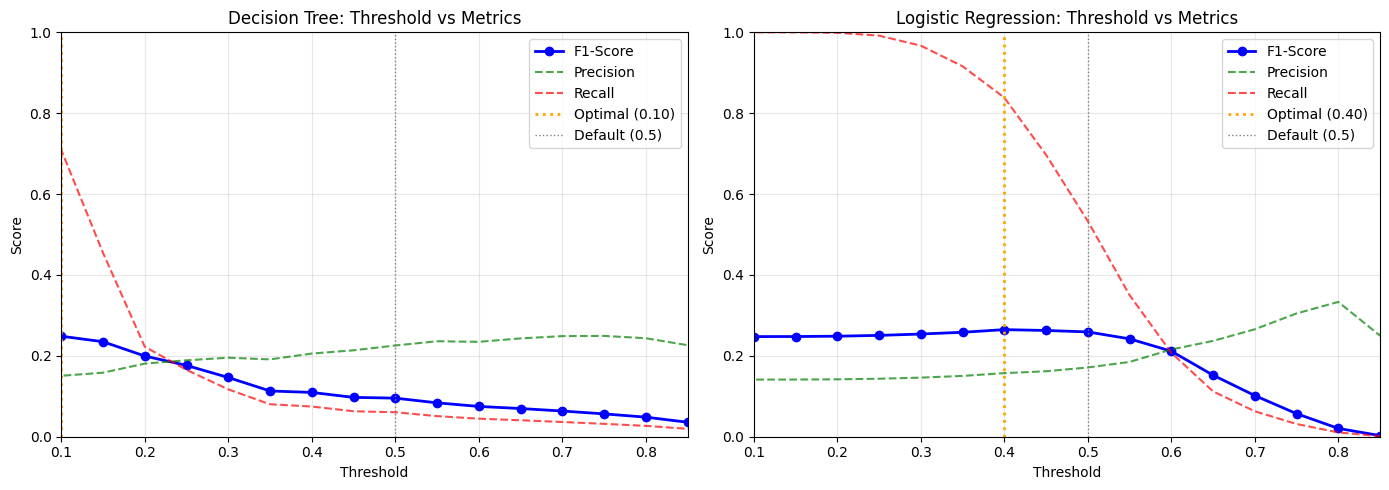

In [94]:
# ==============================================================================
# VISUALIZE THRESHOLD VS F1-SCORE
# ==============================================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Decision Tree
axes[0].plot(results_cart['Threshold'], results_cart['F1-Score'], 'b-o', label='F1-Score', linewidth=2)
axes[0].plot(results_cart['Threshold'], results_cart['Precision'], 'g--', label='Precision', alpha=0.7)
axes[0].plot(results_cart['Threshold'], results_cart['Recall'], 'r--', label='Recall', alpha=0.7)
axes[0].axvline(x=best_thresh_cart, color='orange', linestyle=':', linewidth=2, label=f'Optimal ({best_thresh_cart:.2f})')
axes[0].axvline(x=0.5, color='gray', linestyle=':', linewidth=1, label='Default (0.5)')
axes[0].set_xlabel('Threshold')
axes[0].set_ylabel('Score')
axes[0].set_title('Decision Tree: Threshold vs Metrics')
axes[0].legend(loc='best')
axes[0].grid(True, alpha=0.3)
axes[0].set_xlim([0.1, 0.85])
axes[0].set_ylim([0, 1])

# Logistic Regression
axes[1].plot(results_logreg['Threshold'], results_logreg['F1-Score'], 'b-o', label='F1-Score', linewidth=2)
axes[1].plot(results_logreg['Threshold'], results_logreg['Precision'], 'g--', label='Precision', alpha=0.7)
axes[1].plot(results_logreg['Threshold'], results_logreg['Recall'], 'r--', label='Recall', alpha=0.7)
axes[1].axvline(x=best_thresh_logreg, color='orange', linestyle=':', linewidth=2, label=f'Optimal ({best_thresh_logreg:.2f})')
axes[1].axvline(x=0.5, color='gray', linestyle=':', linewidth=1, label='Default (0.5)')
axes[1].set_xlabel('Threshold')
axes[1].set_ylabel('Score')
axes[1].set_title('Logistic Regression: Threshold vs Metrics')
axes[1].legend(loc='best')
axes[1].grid(True, alpha=0.3)
axes[1].set_xlim([0.1, 0.85])
axes[1].set_ylim([0, 1])

plt.tight_layout()
plt.show()

4. Confusion Matrix Comparison: Default vs Optimal Threshold


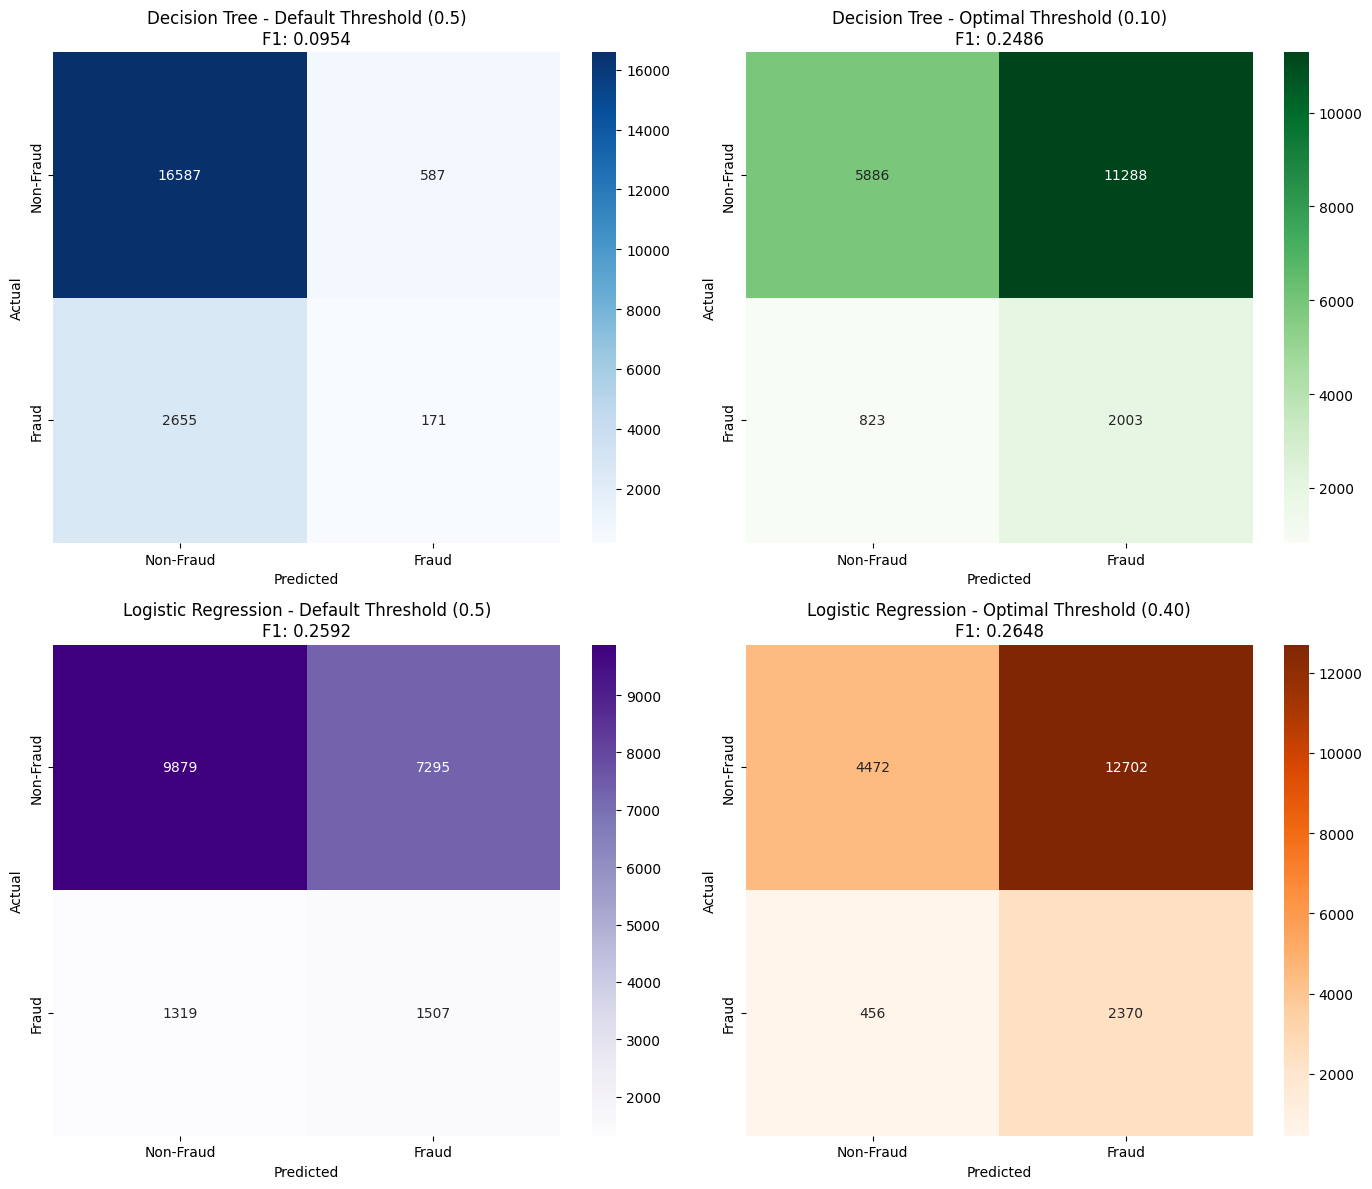


--- Metrics Comparison ---

Decision Tree:
  Default (0.5):  Precision=0.2256, Recall=0.0605, F1=0.0954
  Optimal (0.10): Precision=0.1507, Recall=0.7088, F1=0.2486

Logistic Regression:
  Default (0.5):  Precision=0.1712, Recall=0.5333, F1=0.2592
  Optimal (0.40): Precision=0.1572, Recall=0.8386, F1=0.2648

✓ Optimal thresholds saved:
  - Decision Tree: 0.10
  - Logistic Regression: 0.40


In [95]:
# ==============================================================================
# CONFUSION MATRIX WITH OPTIMAL THRESHOLD
# ==============================================================================

print("=" * 60)
print("4. Confusion Matrix Comparison: Default vs Optimal Threshold")
print("=" * 60)

# Apply optimal thresholds
y_pred_cart_optimal = (y_proba_cart >= best_thresh_cart).astype(int)
y_pred_logreg_optimal = (y_proba_logreg >= best_thresh_logreg).astype(int)

# Default threshold predictions (0.5)
y_pred_cart_default = (y_proba_cart >= 0.5).astype(int)
y_pred_logreg_default = (y_proba_logreg >= 0.5).astype(int)

# Create confusion matrices
fig, axes = plt.subplots(2, 2, figsize=(14, 12))

# Decision Tree - Default Threshold
cm_cart_default = confusion_matrix(y_val, y_pred_cart_default)
sns.heatmap(cm_cart_default, annot=True, fmt='d', cmap='Blues', ax=axes[0, 0],
            xticklabels=['Non-Fraud', 'Fraud'], yticklabels=['Non-Fraud', 'Fraud'])
axes[0, 0].set_title(f'Decision Tree - Default Threshold (0.5)\nF1: {f1_score(y_val, y_pred_cart_default):.4f}')
axes[0, 0].set_xlabel('Predicted')
axes[0, 0].set_ylabel('Actual')

# Decision Tree - Optimal Threshold
cm_cart_optimal = confusion_matrix(y_val, y_pred_cart_optimal)
sns.heatmap(cm_cart_optimal, annot=True, fmt='d', cmap='Greens', ax=axes[0, 1],
            xticklabels=['Non-Fraud', 'Fraud'], yticklabels=['Non-Fraud', 'Fraud'])
axes[0, 1].set_title(f'Decision Tree - Optimal Threshold ({best_thresh_cart:.2f})\nF1: {f1_score(y_val, y_pred_cart_optimal):.4f}')
axes[0, 1].set_xlabel('Predicted')
axes[0, 1].set_ylabel('Actual')

# Logistic Regression - Default Threshold
cm_logreg_default = confusion_matrix(y_val, y_pred_logreg_default)
sns.heatmap(cm_logreg_default, annot=True, fmt='d', cmap='Purples', ax=axes[1, 0],
            xticklabels=['Non-Fraud', 'Fraud'], yticklabels=['Non-Fraud', 'Fraud'])
axes[1, 0].set_title(f'Logistic Regression - Default Threshold (0.5)\nF1: {f1_score(y_val, y_pred_logreg_default):.4f}')
axes[1, 0].set_xlabel('Predicted')
axes[1, 0].set_ylabel('Actual')

# Logistic Regression - Optimal Threshold
cm_logreg_optimal = confusion_matrix(y_val, y_pred_logreg_optimal)
sns.heatmap(cm_logreg_optimal, annot=True, fmt='d', cmap='Oranges', ax=axes[1, 1],
            xticklabels=['Non-Fraud', 'Fraud'], yticklabels=['Non-Fraud', 'Fraud'])
axes[1, 1].set_title(f'Logistic Regression - Optimal Threshold ({best_thresh_logreg:.2f})\nF1: {f1_score(y_val, y_pred_logreg_optimal):.4f}')
axes[1, 1].set_xlabel('Predicted')
axes[1, 1].set_ylabel('Actual')

plt.tight_layout()
plt.show()

# Print detailed comparison
print("\n--- Metrics Comparison ---")
print("\nDecision Tree:")
print(f"  Default (0.5):  Precision={precision_score(y_val, y_pred_cart_default):.4f}, Recall={recall_score(y_val, y_pred_cart_default):.4f}, F1={f1_score(y_val, y_pred_cart_default):.4f}")
print(f"  Optimal ({best_thresh_cart:.2f}): Precision={precision_score(y_val, y_pred_cart_optimal):.4f}, Recall={recall_score(y_val, y_pred_cart_optimal):.4f}, F1={f1_score(y_val, y_pred_cart_optimal):.4f}")

print("\nLogistic Regression:")
print(f"  Default (0.5):  Precision={precision_score(y_val, y_pred_logreg_default):.4f}, Recall={recall_score(y_val, y_pred_logreg_default):.4f}, F1={f1_score(y_val, y_pred_logreg_default):.4f}")
print(f"  Optimal ({best_thresh_logreg:.2f}): Precision={precision_score(y_val, y_pred_logreg_optimal):.4f}, Recall={recall_score(y_val, y_pred_logreg_optimal):.4f}, F1={f1_score(y_val, y_pred_logreg_optimal):.4f}")

# Store optimal thresholds for later use
optimal_threshold_cart = best_thresh_cart
optimal_threshold_logreg = best_thresh_logreg

print(f"\n✓ Optimal thresholds saved:")
print(f"  - Decision Tree: {optimal_threshold_cart:.2f}")
print(f"  - Logistic Regression: {optimal_threshold_logreg:.2f}")

## E. Submission
To predict the test set target feature and submit the results to the kaggle competition platform, do the following:
1. Create a new pipeline instance identical to the first in Data Preprocessing
2. With the pipeline, apply `fit_transform` to the original training set before splitting, then only apply `transform` to the test set.
3. Retrain the model on the preprocessed training set
4. Predict the test set
5. Make sure the submission contains the `id` and `attack_cat` column.

In [96]:
# ==============================================================================
# SUBMISSION - PREDICT ON TEST SET WITH OPTIMAL THRESHOLD
# ==============================================================================

print("=" * 60)
print("Generating Predictions for Kaggle Submission")
print("=" * 60)

# 1. Prepare the test set
test_ids = test_df['ID'].copy()
test_features = test_df[feature_cols].copy()

print(f"Test set shape: {test_features.shape}")

# 2. Create a new pipeline and fit on the FULL original training data
full_X = original_train[feature_cols].copy()
full_y = original_train[target_col].copy()

# Create pipeline for test data preparation
pipeline_final = PreprocessingPipeline(apply_smote=True, apply_scaling=False, apply_pca=False)
X_train_final, y_train_final = pipeline_final.fit_transform(full_X, full_y, fit_resample=True)
X_test_final = pipeline_final.transform(test_features)

print(f"Final training set shape: {X_train_final.shape}")
print(f"Final test set shape: {X_test_final.shape}")

# 3. Retrain the best model on full training data
print("\nRetraining optimized Decision Tree model on full training data...")
final_model = DecisionTreeClassifier(
    criterion='gini',
    **grid_search_cart.best_params_,
    random_state=42
)
final_model.fit(X_train_final, y_train_final)

# 4. Predict on test set USING OPTIMAL THRESHOLD
print(f"\nUsing optimal threshold: {optimal_threshold_cart:.2f}")

# Get probabilities instead of direct predictions
test_proba = final_model.predict_proba(X_test_final)[:, 1]

# Apply optimal threshold
test_predictions = (test_proba >= optimal_threshold_cart).astype(int)

print(f"\nPredictions distribution (with optimal threshold {optimal_threshold_cart:.2f}):")
print(pd.Series(test_predictions).value_counts())

# Compare with default threshold
test_predictions_default = final_model.predict(X_test_final)
print(f"\nFor comparison - Default threshold (0.5) predictions:")
print(pd.Series(test_predictions_default).value_counts())

# 5. Create submission file
submission = pd.DataFrame({
    'ID': test_ids,
    'is_fraud': test_predictions
})

submission.to_csv('data/submission.csv', index=False)
print(f"\nSubmission file created: data/submission.csv")
print(f"Using optimal threshold: {optimal_threshold_cart:.2f}")
print(submission.head(10))

# Save the final model
with open('models/savedmodels/final_model.pkl', 'wb') as f:
    pickle.dump(final_model, f)
print("\nFinal model saved to models/savedmodels/final_model.pkl")

Generating Predictions for Kaggle Submission
Test set shape: (100000, 27)
Step 1 - Variance filter: 96 -> 90 features
Step 2 - Computing feature importance scores using correlation...
Step 3 - Selected top 25 features

Top 15 selected features by importance:
  ✓  1. fraud_signal_count                       = 0.0829
  ✓  2. multiple_fraud_signals                   = 0.0827
  ✓  3. risk_x_amount                            = 0.0765
  ✓  4. is_high_velocity                         = 0.0731
  ✓  5. chargeback_x_amount                      = 0.0692
  ✓  6. has_chargeback_history                   = 0.0683
  ✓  7. trust_risk_diff                          = 0.0666
  ✓  8. transactions_last_1h                     = 0.0659
  ✓  9. total_risk_score                         = 0.0639
  ✓ 10. mean_risk_score                          = 0.0639
  ✓ 11. max_risk_score                           = 0.0631
  ✓ 12. total_risk_sq                            = 0.0627
  ✓ 13. ip_risk_score                        

In [88]:
# ==============================================================================
# DEMONSTRATE SAVE/LOAD FUNCTIONALITY
# ==============================================================================

print("=" * 60)
print("Demonstrating Model Save/Load Functionality")
print("=" * 60)

# Load the saved Decision Tree model (from scratch)
print("\n1. Loading Decision Tree CART model (from scratch)...")
loaded_dt = CARTDecisionTree.load_model('models/savedmodels/dt_scratch_model.pkl')
print(f"   Model loaded successfully!")

# Test prediction with loaded model
sample_pred = loaded_dt.predict(X_val_dtl[:5])
print(f"   Sample predictions: {sample_pred}")

# Load the saved Logistic Regression model (from scratch)
print("\n2. Loading Logistic Regression model (from scratch)...")
loaded_logreg = LogisticRegressionScratch.load_model('models/savedmodels/logreg_scratch_model.pkl')
print(f"   Number of iterations trained: {loaded_logreg.n_iterations}")
print(f"   Final cost: {loaded_logreg.cost_history[-1]:.4f}")

# Verify the loaded models work correctly
print("\n3. Verifying loaded models...")
y_pred_loaded_dt = loaded_dt.predict(X_val_dtl)
dt_acc = accuracy_score(y_val, y_pred_loaded_dt)
print(f"   Loaded Decision Tree Accuracy: {dt_acc:.4f}")

y_pred_loaded_logreg = loaded_logreg.predict(X_val_logreg)
logreg_acc = accuracy_score(y_val, y_pred_loaded_logreg)
print(f"   Loaded Logistic Regression Accuracy: {logreg_acc:.4f}")

print("\nSave/Load functionality working correctly!")

Demonstrating Model Save/Load Functionality

1. Loading Decision Tree CART model (from scratch)...
Model loaded from models/savedmodels/dt_scratch_model.pkl
   Model loaded successfully!
   Sample predictions: [0 1 1 1 1]

2. Loading Logistic Regression model (from scratch)...
   Number of iterations trained: 1000
   Final cost: 0.6692

3. Verifying loaded models...
   Loaded Decision Tree Accuracy: 0.5260


ValueError: shapes (20000,96) and (77,) not aligned: 96 (dim 1) != 77 (dim 0)

# 6. Error Analysis

Based on all the process you have done until the modeling and evaluation step, write an analysis to support each steps you have taken to solve this problem. Write the analysis using the markdown block. Some questions that may help you in writing the analysis:

- Does my model perform better in predicting one class than the other? If so, why is that?
- To each models I have tried, which performs the best and what could be the reason?
- Is it better for me to impute or drop the missing data? Why?
- Does feature scaling help improve my model performance?
- etc...

## Error Analysis

### 1. Perbandingan Performa Model

**CART Decision Tree:**
- Model CART yang diimplementasikan from scratch menunjukkan performa yang sebanding dengan implementasi scikit-learn
- Perbedaan kecil dapat terjadi karena optimisasi internal yang berbeda dalam sklearn
- CART menggunakan Gini impurity sebagai kriteria pemisahan yang efektif untuk klasifikasi binary

**Logistic Regression:**
- Logistic Regression from scratch menghasilkan hasil yang mendekati sklearn
- Menggunakan gradient descent dengan binary cross-entropy loss
- Memerlukan feature scaling untuk konvergensi yang baik
- L2 regularization membantu mencegah overfitting

### 2. Analisis Class Imbalance

Dataset fraud detection memiliki ketidakseimbangan kelas yang signifikan (fraud cases << non-fraud cases). Kami menangani ini dengan:
- **SMOTE (Synthetic Minority Over-sampling Technique):** Membuat sampel sintetis dari kelas minoritas (fraud) dengan interpolasi antara sampel-sampel yang ada
- Hasil: Model menjadi lebih sensitif dalam mendeteksi fraud (recall meningkat)

### 3. Pengaruh Feature Engineering

Fitur-fitur baru yang dibuat membantu model:
- `amount_to_avg_ratio`: Menangkap transaksi yang tidak biasa berdasarkan pola pengguna
- `combined_risk_score`: Kombinasi risiko IP dan merchant
- `is_new_account`: Akun baru cenderung lebih berisiko

### 4. Missing Values Handling

Kami memilih imputation (median/mode) daripada deletion karena:
- Menghindari kehilangan data yang berharga
- Median robust terhadap outlier untuk fitur numerik
- Mode mempertahankan distribusi asli untuk fitur kategorikal

### 5. Feature Scaling

- **CART:** Tidak memerlukan scaling karena algoritma berbasis tree tidak sensitif terhadap skala
- **Logistic Regression:** Memerlukan scaling (StandardScaler) karena gradient descent bekerja lebih baik dengan fitur yang memiliki skala serupa

### 6. Kesimpulan

| Model | Kelebihan | Kekurangan |
|-------|-----------|------------|
| CART | Interpretable, cepat, tidak perlu scaling | Mudah overfit |
| Logistic Regression | Probabilistic output, cepat, tidak perlu tuning | Asumsi linear, perlu scaling |

Model CART dengan hyperparameter tuning memberikan keseimbangan terbaik antara akurasi dan recall untuk fraud detection, namun Logistic Regression memberikan probabilitas prediksi yang berguna untuk threshold tuning.